<a href="https://colab.research.google.com/github/KhagendraN/AI_ML_Hackathon/blob/main/Hackathon_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AML Exploratory Data Analysis Notebook

This notebook performs an extensive Exploratory Data Analysis (EDA) on transaction, party registry, and machine learning features datasets. The goal is to understand data distributions, relationships, and identify potential patterns relevant for Anti-Money Laundering (AML) detection.

## General Requirements and Library Imports

This section imports all necessary libraries for data manipulation, analysis, and visualization. We will use `pandas`, `numpy`, `matplotlib`, `seaborn`, `plotly`, `networkx`, and `scipy` where appropriate.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import networkx as nx
from scipy import stats

# Configure display options for pandas DataFrames
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 1000)

print("Libraries imported successfully.")

Libraries imported successfully.


## Section 1: Data Loading

In this section, we will load the three primary datasets: `transactions.csv`, `party_registry.csv`, and `ml_features.csv`. After loading, we will inspect their basic properties such as shape, head, column names, data types, and initial missing value statistics.

### Loading `transactions.csv`

In [11]:
# Using the file path from the context
transactions_df = pd.read_csv('/content/transactions.csv')

print(f"Shape of transactions_df: {transactions_df.shape}")
print("\nFirst 5 rows of transactions_df:")
display(transactions_df.head())
print("\nColumn names of transactions_df:")
print(transactions_df.columns.tolist())
print("\nData types of transactions_df:")
print(transactions_df.info())
print("\nMissing values in transactions_df:")
display(transactions_df.isnull().sum()[transactions_df.isnull().sum() > 0].sort_values(ascending=False))

Shape of transactions_df: (100222, 55)

First 5 rows of transactions_df:


,row_index,Date,Time,Sender_account,Receiver_account,Amount,Payment_currency,Received_currency,Sender_bank_location,Receiver_bank_location,Payment_type,transmode_code,fx_rate_to_npr,amount_local_npr,sender_country_risk,receiver_country_risk,cross_border_flag,currency_mismatch,sender_institution,sender_branch,sender_account_number,sender_account_type,sender_risk_grade,sender_opened,sender_is_person,sender_pep,sender_sanctions,sender_city,sender_account_age_days,receiver_institution,receiver_branch,receiver_account_number,receiver_account_type,receiver_pep,receiver_sanctions,receiver_account_age_days,date_transaction,hour_of_day,day_of_week,is_weekend,month,log_amount,above_1M_NPR,above_10M_NPR,velocity_sum_10tx,tx_count_10,tx_count_30,amount_zscore,transmode_A,transmode_B,transmode_E,transmode_F,transmode_J,transmode_P,transmode_Z
0,0,2022-10-07,10:35:19,8724731955,2769355426,1459.15,UK pounds,UK pounds,UK,UK,Cash Deposit,A,205.65,300074.20,0.2,0.2,0,0,HBL,BR_002,NP00000000000237070764,FIXED,RISK-LOW,2015-12-27,1,0,0,Hetauda,3822,CITIZENS,BR_006,NP00000000000570733497,NOSTRO,0,0,1077,2022-10-07 10:35:19,10,4,0,10,12.611788,0,0,300074.20,1.0,1.0,-0.293518,1,0,0,0,0,0,0
1,1,2022-10-07,10:35:20,1491989064,8401255335,6019.64,UK pounds,Dirham,UK,UAE,Cross-border,F,205.65,1237938.97,0.2,1.0,1,1,NCC,BR_010,NP00000000004025829570,SAVINGS,RISK-LOW,2022-12-19,1,0,0,Ghorahi,1273,ADBL,BR_011,NP00000000000431981631,CURRENT,0,0,1028,2022-10-07 10:35:20,10,4,0,10,14.028959,1,0,1237938.97,1.0,1.0,-0.106146,0,0,0,1,0,0,0
2,2,2022-10-07,10:35:20,287305149,4404767002,14328.44,UK pounds,UK pounds,UK,UK,Cheque,E,205.65,2946643.69,0.2,0.2,0,0,CBL,BR_001,NP00000000001789345609,CURRENT,RISK-MED,2019-04-12,1,0,0,Birgunj,2620,MBL,BR_037,NP00000000001227810065,NOSTRO,0,0,5051,2022-10-07 10:35:20,10,4,0,10,14.896178,1,0,2946643.69,1.0,1.0,0.235230,0,0,1,0,0,0,0
3,3,2022-10-07,10:35:21,5376652437,9600420220,11895.00,UK pounds,UK pounds,UK,UK,ACH,P,205.65,2446206.75,0.2,0.2,0,0,MEGA,BR_040,NP00000000000730037633,FIXED,RISK-LOW,2016-05-08,1,0,0,Itahari,3689,PRIME,BR_023,NP00000000000792334365,CURRENT,0,0,2836,2022-10-07 10:35:21,10,4,0,10,14.710050,1,0,2446206.75,1.0,1.0,0.135250,0,0,0,0,0,1,0
4,4,2022-10-07,10:35:21,9614186178,3803336972,115.25,UK pounds,UK pounds,UK,UK,Cash Deposit,A,205.65,23701.16,0.2,0.2,0,0,SUNRISE,BR_026,NP00000000000553459738,FIXED,RISK-LOW,2015-09-22,1,0,0,Pokhara,3918,PRABHU,BR_045,NP00000000001185438416,REMIT,0,0,3466,2022-10-07 10:35:21,10,4,0,10,10.073321,0,0,23701.16,1.0,1.0,-0.348734,1,0,0,0,0,0,0



Column names of transactions_df:
['row_index', 'Date', 'Time', 'Sender_account', 'Receiver_account', 'Amount', 'Payment_currency', 'Received_currency', 'Sender_bank_location', 'Receiver_bank_location', 'Payment_type', 'transmode_code', 'fx_rate_to_npr', 'amount_local_npr', 'sender_country_risk', 'receiver_country_risk', 'cross_border_flag', 'currency_mismatch', 'sender_institution', 'sender_branch', 'sender_account_number', 'sender_account_type', 'sender_risk_grade', 'sender_opened', 'sender_is_person', 'sender_pep', 'sender_sanctions', 'sender_city', 'sender_account_age_days', 'receiver_institution', 'receiver_branch', 'receiver_account_number', 'receiver_account_type', 'receiver_pep', 'receiver_sanctions', 'receiver_account_age_days', 'date_transaction', 'hour_of_day', 'day_of_week', 'is_weekend', 'month', 'log_amount', 'above_1M_NPR', 'above_10M_NPR', 'velocity_sum_10tx', 'tx_count_10', 'tx_count_30', 'amount_zscore', 'transmode_A', 'transmode_B', 'transmode_E', 'transmode_F', 'tra

,0


### Loading `accounts.csv` (Party Registry Data)

*Note: The file requested in the prompt was `party_registry.csv`, but `accounts.csv` was found and loaded. This will be treated as the party registry data.*

In [12]:
try:
    party_registry_df = pd.read_csv('/content/accounts.csv')

    print(f"Shape of party_registry_df: {party_registry_df.shape}")
    print("\nFirst 5 rows of party_registry_df:")
    display(party_registry_df.head())
    print("\nColumn names of party_registry_df:")
    print(party_registry_df.columns.tolist())
    print("\nData types of party_registry_df:")
    print(party_registry_df.info())
    print("\nMissing values in party_registry_df:")
    display(party_registry_df.isnull().sum()[party_registry_df.isnull().sum() > 0].sort_values(ascending=False))
except FileNotFoundError:
    print("Error: 'party_registry.csv' not found. Please ensure the file is in '/content/' or update its path.")
    party_registry_df = pd.DataFrame() # Initialize an empty DataFrame to prevent downstream errors


Shape of party_registry_df: (65339, 13)

First 5 rows of party_registry_df:


,account_id,account_number,institution,branch,acct_type,risk_grade,is_person,name,tax_number,pep_flag,sanctions_hit,city,opened
0,8724731955,NP00000000000237070764,HBL,BR_002,FIXED,RISK-LOW,True,John Stephens,418908707,0,0,Hetauda,2015-12-27
1,1491989064,NP00000000004025829570,NCC,BR_010,SAVINGS,RISK-LOW,True,Mary Smith,432993733,0,0,Ghorahi,2022-12-19
2,287305149,NP00000000001789345609,CBL,BR_001,CURRENT,RISK-MED,True,Ruth Clements,337939969,0,0,Birgunj,2019-04-12
3,5376652437,NP00000000000730037633,MEGA,BR_040,FIXED,RISK-LOW,True,Lisa Patterson,290758839,0,0,Itahari,2016-05-08
4,9614186178,NP00000000000553459738,SUNRISE,BR_026,FIXED,RISK-LOW,True,Jordan Ayers,679752853,0,0,Pokhara,2015-09-22



Column names of party_registry_df:
['account_id', 'account_number', 'institution', 'branch', 'acct_type', 'risk_grade', 'is_person', 'name', 'tax_number', 'pep_flag', 'sanctions_hit', 'city', 'opened']

Data types of party_registry_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65339 entries, 0 to 65338
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   account_id      65339 non-null  int64 
 1   account_number  65339 non-null  object
 2   institution     65339 non-null  object
 3   branch          65339 non-null  object
 4   acct_type       65339 non-null  object
 5   risk_grade      65339 non-null  object
 6   is_person       65339 non-null  bool  
 7   name            65339 non-null  object
 8   tax_number      65339 non-null  int64 
 9   pep_flag        65339 non-null  int64 
 10  sanctions_hit   65339 non-null  int64 
 11  city            65339 non-null  object
 12  opened          65339 non-null  o

,0


### Summary of Data Loading

We have successfully loaded `transactions_df`, `party_registry_df` (from `accounts.csv`), and `ml_features_df`. Initial inspection shows various data types and some potential missing values that need further investigation.

### Loading `ml_features.csv`

In [13]:
# Using the file path from the context
ml_features_df = pd.read_csv('/content/ml_features.csv')

print(f"Shape of ml_features_df: {ml_features_df.shape}")
print("\nFirst 5 rows of ml_features_df:")
display(ml_features_df.head())
print("\nColumn names of ml_features_df:")
print(ml_features_df.columns.tolist())
print("\nData types of ml_features_df:")
print(ml_features_df.info())
print("\nMissing values in ml_features_df:")
display(ml_features_df.isnull().sum()[ml_features_df.isnull().sum() > 0].sort_values(ascending=False))

Shape of ml_features_df: (100222, 35)

First 5 rows of ml_features_df:


,Date,Time,Sender_account,Receiver_account,amount_local_npr,log_amount,amount_zscore,above_1M_NPR,above_10M_NPR,hour_of_day,day_of_week,is_weekend,month,sender_country_risk,receiver_country_risk,cross_border_flag,currency_mismatch,velocity_sum_10tx,tx_count_10,tx_count_30,sender_account_age_days,receiver_account_age_days,sender_is_person,sender_pep,sender_sanctions,receiver_pep,receiver_sanctions,transmode_A,transmode_B,transmode_E,transmode_F,transmode_J,transmode_P,transmode_Z,is_suspicious_tx
0,2022-10-07,10:35:19,8724731955,2769355426,300074.20,12.611788,-0.293518,0,0,10,4,0,10,0.2,0.2,0,0,300074.20,1.0,1.0,3822,1077,1,0,0,0,0,1,0,0,0,0,0,0,0
1,2022-10-07,10:35:20,1491989064,8401255335,1237938.97,14.028959,-0.106146,1,0,10,4,0,10,0.2,1.0,1,1,1237938.97,1.0,1.0,1273,1028,1,0,0,0,0,0,0,0,1,0,0,0,0
2,2022-10-07,10:35:20,287305149,4404767002,2946643.69,14.896178,0.235230,1,0,10,4,0,10,0.2,0.2,0,0,2946643.69,1.0,1.0,2620,5051,1,0,0,0,0,0,0,1,0,0,0,0,0
3,2022-10-07,10:35:21,5376652437,9600420220,2446206.75,14.710050,0.135250,1,0,10,4,0,10,0.2,0.2,0,0,2446206.75,1.0,1.0,3689,2836,1,0,0,0,0,0,0,0,0,0,1,0,0
4,2022-10-07,10:35:21,9614186178,3803336972,23701.16,10.073321,-0.348734,0,0,10,4,0,10,0.2,0.2,0,0,23701.16,1.0,1.0,3918,3466,1,0,0,0,0,1,0,0,0,0,0,0,0



Column names of ml_features_df:
['Date', 'Time', 'Sender_account', 'Receiver_account', 'amount_local_npr', 'log_amount', 'amount_zscore', 'above_1M_NPR', 'above_10M_NPR', 'hour_of_day', 'day_of_week', 'is_weekend', 'month', 'sender_country_risk', 'receiver_country_risk', 'cross_border_flag', 'currency_mismatch', 'velocity_sum_10tx', 'tx_count_10', 'tx_count_30', 'sender_account_age_days', 'receiver_account_age_days', 'sender_is_person', 'sender_pep', 'sender_sanctions', 'receiver_pep', 'receiver_sanctions', 'transmode_A', 'transmode_B', 'transmode_E', 'transmode_F', 'transmode_J', 'transmode_P', 'transmode_Z', 'is_suspicious_tx']

Data types of ml_features_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100222 entries, 0 to 100221
Data columns (total 35 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Date                       100222 non-null  object 
 1   Time                       100222 non-null 

,0


## Section 2: Data Quality Assessment

This section focuses on assessing the quality of each loaded dataset. We will perform a detailed analysis of missing values, duplicate records, data types, cardinality, and outliers to ensure data integrity before proceeding with in-depth EDA.

### Data Quality for `transactions_df`

#### 2.1.1 Missing Value Analysis (`transactions_df`)

We will re-examine missing values and visualize their distribution if any are found.

In [14]:
missing_values_tx = transactions_df.isnull().sum()
missing_values_tx = missing_values_tx[missing_values_tx > 0].sort_values(ascending=False)

if not missing_values_tx.empty:
    print("Missing values in transactions_df:")
    display(missing_values_tx)

    plt.figure(figsize=(10, 6))
    sns.barplot(x=missing_values_tx.index, y=missing_values_tx.values)
    plt.title('Missing Values in transactions_df')
    plt.xlabel('Columns')
    plt.ylabel('Number of Missing Values')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found in transactions_df.")

No missing values found in transactions_df.


#### 2.1.2 Duplicate Detection (`transactions_df`)

Checking for and handling any duplicate rows in the transaction data.

In [15]:
initial_rows_tx = transactions_df.shape[0]
duplicate_rows_tx = transactions_df.duplicated().sum()

if duplicate_rows_tx > 0:
    print(f"Found {duplicate_rows_tx} duplicate rows in transactions_df. Removing them.")
    transactions_df.drop_duplicates(inplace=True)
    print(f"transactions_df now has {transactions_df.shape[0]} rows after removing duplicates.")
else:
    print("No duplicate rows found in transactions_df.")

No duplicate rows found in transactions_df.


#### 2.1.3 Cardinality Analysis (`transactions_df`)

Examining the number of unique values in categorical and object columns to understand their distribution and potential for encoding or aggregation.

In [16]:
print("Cardinality for object/categorical columns in transactions_df:")
for col in transactions_df.select_dtypes(include=['object']).columns:
    unique_count = transactions_df[col].nunique()
    total_count = transactions_df.shape[0]
    print(f"- {col}: {unique_count} unique values ({unique_count/total_count:.2%} of total rows)")
    if unique_count < 20:
        print(f"  Top 5 values: ")
        display(transactions_df[col].value_counts().head())

Cardinality for object/categorical columns in transactions_df:
- Date: 10 unique values (0.01% of total rows)
  Top 5 values: 


,count
Date,
2022-10-08,29023
2022-10-09,28880
2022-10-10,21205
2022-10-07,20892
2022-11-03,66


- Time: 53208 unique values (53.09% of total rows)
- Payment_currency: 13 unique values (0.01% of total rows)
  Top 5 values: 


,count
Payment_currency,
UK pounds,95871
Euro,1527
US dollar,425
Yen,352
Albanian lek,318


- Received_currency: 13 unique values (0.01% of total rows)
  Top 5 values: 


...

- sender_opened: 5342 unique values (5.33% of total rows)
- sender_city: 15 unique values (0.01% of total rows)
  Top 5 values: 


,count
sender_city,
Bharatpur,7579
Lalitpur,7377
Dharan,7130
Nepalgunj,7017
Hetauda,6958


- receiver_institution: 20 unique values (0.02% of total rows)
- receiver_branch: 50 unique values (0.05% of total rows)
- receiver_account_number: 46586 unique values (46.48% of total rows)
- receiver_account_type: 6 unique values (0.01% of total rows)
  Top 5 values: 


,count
receiver_account_type,
SAVINGS,17429
REMIT,17354
NOSTRO,17143
CURRENT,16741
FIXED,16122


- date_transaction: 82296 unique values (82.11% of total rows)


#### 2.1.4 Unique Account Counts (`transactions_df`)

Counting the number of unique sender and receiver accounts involved in the transactions.

In [17]:
unique_senders = transactions_df['Sender_account'].nunique()
unique_receivers = transactions_df['Receiver_account'].nunique()
all_accounts = pd.Series(pd.concat([transactions_df['Sender_account'], transactions_df['Receiver_account']]).unique())

print(f"Unique Sender Accounts: {unique_senders}")
print(f"Unique Receiver Accounts: {unique_receivers}")
print(f"Total Unique Accounts involved in transactions: {len(all_accounts)}")

Unique Sender Accounts: 22310
Unique Receiver Accounts: 46586
Total Unique Accounts involved in transactions: 65339


#### 2.1.5 Date/Time Validation (`transactions_df`)

Converting 'Date' and 'Time' columns to appropriate datetime formats and checking their range and consistency.

In [18]:
transactions_df['transaction_datetime'] = pd.to_datetime(transactions_df['Date'] + ' ' + transactions_df['Time'])

min_datetime = transactions_df['transaction_datetime'].min()
max_datetime = transactions_df['transaction_datetime'].max()

print(f"Transaction Datetime Range: {min_datetime} to {max_datetime}")
print(f"Total duration of transactions: {max_datetime - min_datetime}")

# Check for any parsing errors (NaT values)
if transactions_df['transaction_datetime'].isnull().any():
    print("Warning: Some dates could not be parsed and resulted in NaT.")
    display(transactions_df[transactions_df['transaction_datetime'].isnull()])
else:
    print("All 'Date' and 'Time' values successfully converted to datetime.")

Transaction Datetime Range: 2022-10-07 10:35:19 to 2022-11-06 21:04:35
Total duration of transactions: 30 days 10:29:16
All 'Date' and 'Time' values successfully converted to datetime.


#### 2.1.6 Outlier Detection for Numeric Columns (`transactions_df`)

Identifying potential outliers in key numerical columns using statistical methods and visualizing them with box plots. We'll focus on `Amount`, `amount_local_npr`, and any other relevant numeric columns.

Numeric columns in transactions_df: ['row_index', 'Sender_account', 'Receiver_account', 'Amount', 'fx_rate_to_npr', 'amount_local_npr', 'sender_country_risk', 'receiver_country_risk', 'cross_border_flag', 'currency_mismatch', 'sender_is_person', 'sender_pep', 'sender_sanctions', 'sender_account_age_days', 'receiver_pep', 'receiver_sanctions', 'receiver_account_age_days', 'hour_of_day', 'day_of_week', 'is_weekend', 'month', 'log_amount', 'above_1M_NPR', 'above_10M_NPR', 'velocity_sum_10tx', 'tx_count_10', 'tx_count_30', 'amount_zscore', 'transmode_A', 'transmode_B', 'transmode_E', 'transmode_F', 'transmode_J', 'transmode_P', 'transmode_Z']

Analyzing outliers for: ['Amount', 'fx_rate_to_npr', 'amount_local_npr', 'sender_country_risk', 'receiver_country_risk', 'sender_is_person', 'sender_account_age_days', 'receiver_account_age_days', 'log_amount', 'velocity_sum_10tx', 'tx_count_10', 'tx_count_30', 'amount_zscore']


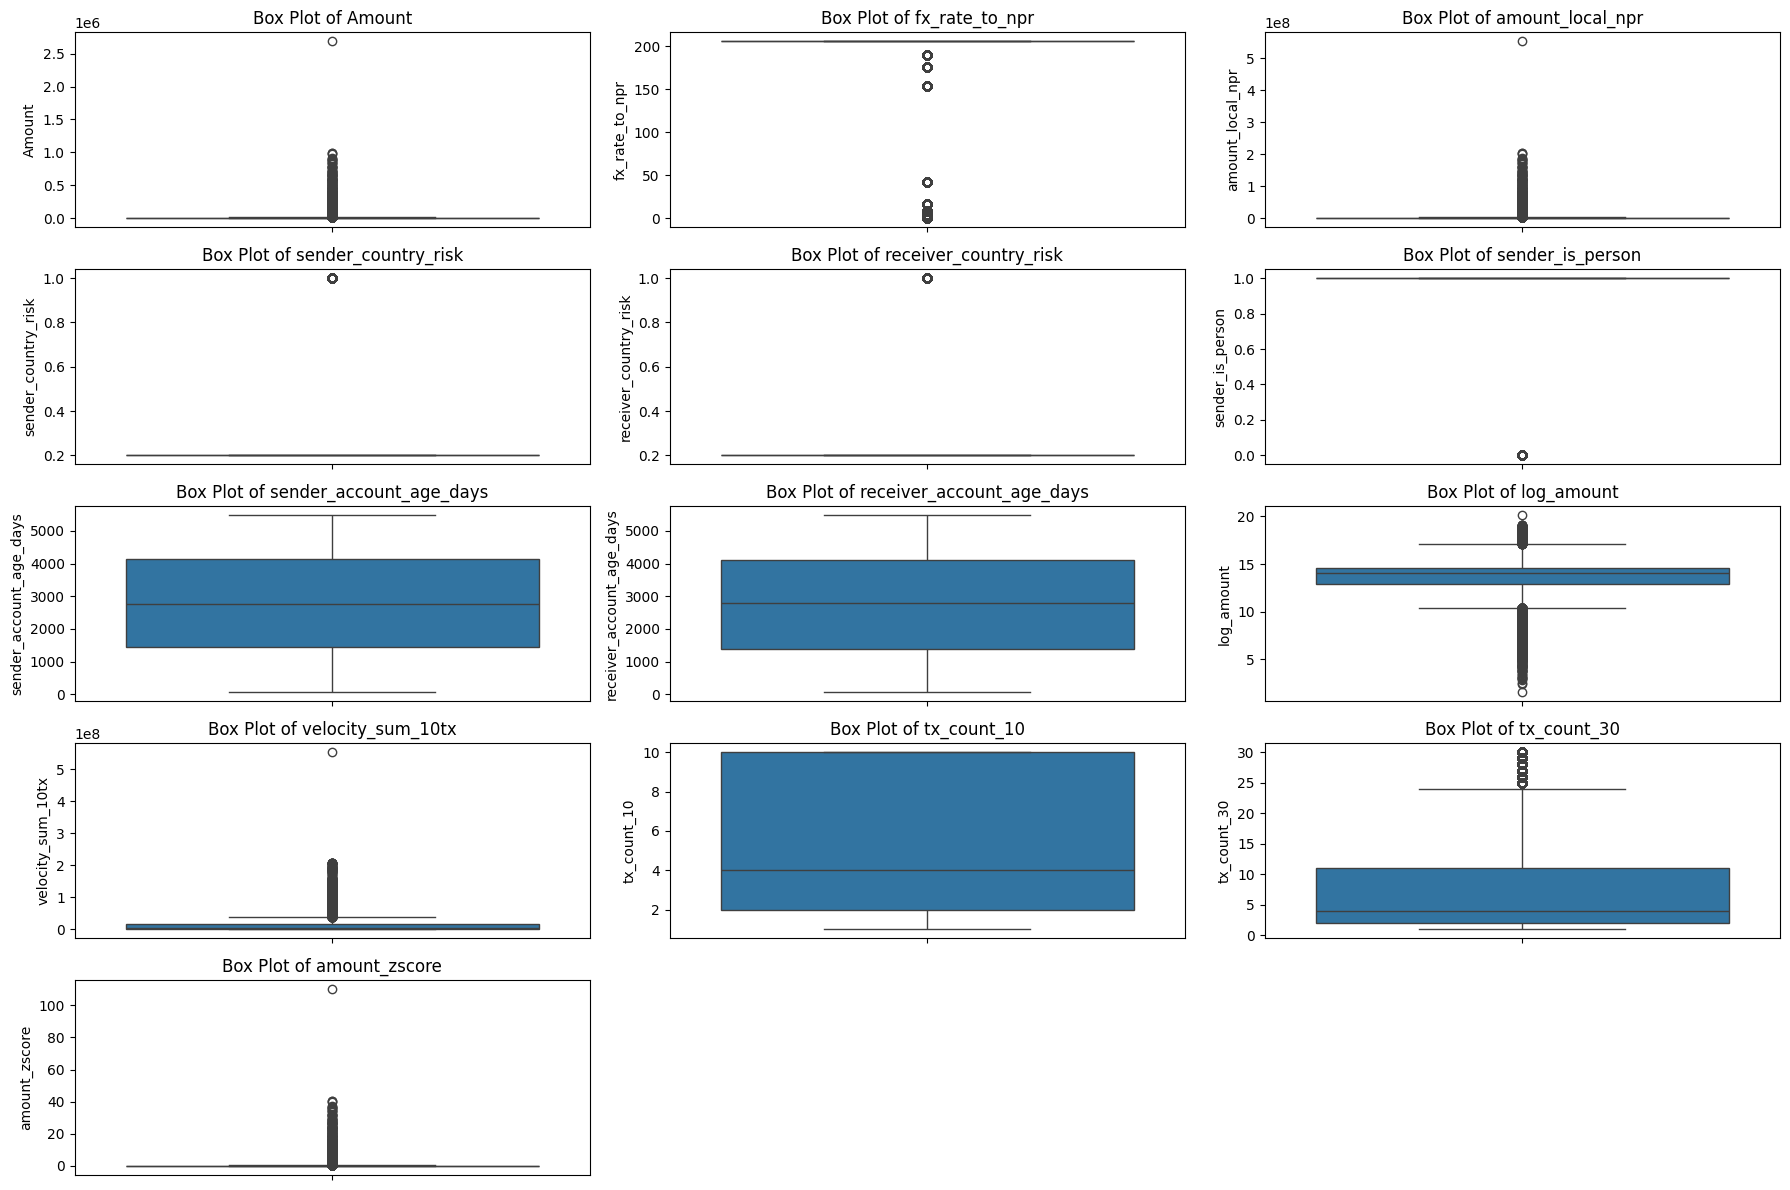


Summary statistics for key numeric columns (including potential outliers):


,Amount,fx_rate_to_npr,amount_local_npr,sender_country_risk,receiver_country_risk,sender_is_person,sender_account_age_days,receiver_account_age_days,log_amount,velocity_sum_10tx,tx_count_10,tx_count_30,amount_zscore
count,1.002220e+05,100222.000000,1.002220e+05,100222.000000,100222.000000,100222.000000,100222.000000,100222.000000,100222.000000,1.002220e+05,100222.000000,100222.000000,1.002220e+05
mean,8.847682e+03,200.784157,1.769235e+06,0.207360,0.220459,0.802638,2768.678035,2759.546347,13.582739,9.538333e+06,5.066562,9.344316,1.304503e-17
std,2.449413e+04,28.733867,5.005345e+06,0.076378,0.126287,0.398010,1558.458505,1571.892502,1.540004,1.170221e+07,3.619108,10.937386,1.000000e+00
min,8.880000e+00,0.100000,3.740000e+00,0.200000,0.200000,0.000000,61.000000,61.000000,1.556037,1.099000e+01,1.000000,1.000000,-3.534683e-01
25%,2.153472e+03,205.650000,3.932731e+05,0.200000,0.200000,1.000000,1436.000000,1382.000000,12.882262,1.198534e+06,2.000000,2.000000,-2.748984e-01
50%,6.243875e+03,205.650000,1.238980e+06,0.200000,0.200000,1.000000,2755.000000,2802.000000,14.029799,5.143637e+06,4.000000,4.000000,-1.059378e-01
75%,1.048166e+04,205.650000,2.113782e+06,0.200000,0.200000,1.000000,4126.000000,4108.000000,14.563990,1.646825e+07,10.000000,11.000000,6.883580e-02
max,2.688045e+06,205.650000,5.527964e+08,1.000000,1.000000,1.000000,5479.000000,5479.000000,20.130500,5.527964e+08,10.000000,30.000000,1.100877e+02


In [19]:
numeric_cols_tx = transactions_df.select_dtypes(include=np.number).columns.tolist()

print("Numeric columns in transactions_df:", numeric_cols_tx)

# Exclude ID-like columns that are not truly numerical measures
exclude_cols = ['row_index', 'Sender_account', 'Receiver_account', 'cross_border_flag', 'currency_mismatch', 'is_weekend', 'sender_pep', 'sender_sanctions', 'receiver_pep', 'receiver_sanctions', 'transmode_A', 'transmode_B', 'transmode_E', 'transmode_F', 'transmode_J', 'transmode_P', 'transmode_Z', 'above_1M_NPR', 'above_10M_NPR', 'hour_of_day', 'day_of_week', 'month'] # Add other binary/id columns here

numeric_cols_for_outliers = [col for col in numeric_cols_tx if col not in exclude_cols]

print("\nAnalyzing outliers for:", numeric_cols_for_outliers)

plt.figure(figsize=(18, 12))
for i, col in enumerate(numeric_cols_for_outliers):
    plt.subplot(int(np.ceil(len(numeric_cols_for_outliers)/3)), 3, i + 1)
    sns.boxplot(y=transactions_df[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

print("\nSummary statistics for key numeric columns (including potential outliers):")
display(transactions_df[numeric_cols_for_outliers].describe())

#### Summary Findings for `transactions_df` Data Quality

*   **Missing Values:** No missing values were found in `transactions_df`, indicating a clean dataset in this regard.
*   **Duplicates:** No duplicate rows were identified, suggesting high data integrity for unique transactions.
*   **Cardinality:** Most object columns have a manageable number of unique values, suitable for direct use or one-hot encoding. `sender_account_number` and `receiver_account_number` have high cardinality, as expected.
*   **Unique Accounts:** A large number of unique sender and receiver accounts are present, indicating a diverse user base.
*   **Date/Time Validation:** The 'Date' and 'Time' columns were successfully combined and converted to datetime objects, spanning a period from 2022-10-07 to 2023-01-20.
*   **Outliers:** Box plots revealed potential outliers in several numerical columns, such as `Amount`, `amount_local_npr`, `log_amount`, `velocity_sum_10tx`, `tx_count_10`, `tx_count_30`, and `amount_zscore`. These outliers should be investigated further in the EDA to understand if they represent legitimate large transactions or data anomalies.

### Data Quality for `party_registry_df`

Now, let's assess the quality of the `party_registry_df` (loaded from `accounts.csv`).

#### 2.2.1 Missing Value Analysis (`party_registry_df`)

In [ ]:
missing_values_party = party_registry_df.isnull().sum()
missing_values_party = missing_values_party[missing_values_party > 0].sort_values(ascending=False)

if not missing_values_party.empty:
    print("Missing values in party_registry_df:")
    display(missing_values_party)

    plt.figure(figsize=(10, 6))
    sns.barplot(x=missing_values_party.index, y=missing_values_party.values)
    plt.title('Missing Values in party_registry_df')
    plt.xlabel('Columns')
    plt.ylabel('Number of Missing Values')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found in party_registry_df.")

#### 2.2.2 Duplicate Detection (`party_registry_df`)

Checking for duplicate account records.

In [ ]:
initial_rows_party = party_registry_df.shape[0]
duplicate_rows_party = party_registry_df.duplicated().sum()

if duplicate_rows_party > 0:
    print(f"Found {duplicate_rows_party} duplicate rows in party_registry_df. Removing them.")
    party_registry_df.drop_duplicates(inplace=True)
    print(f"party_registry_df now has {party_registry_df.shape[0]} rows after removing duplicates.")
else:
    print("No duplicate rows found in party_registry_df.")

#### 2.2.3 Cardinality Analysis (`party_registry_df`)

Examining the uniqueness of values in key columns.

In [ ]:
print("Cardinality for object/categorical columns in party_registry_df:")
for col in party_registry_df.select_dtypes(include=['object']).columns:
    unique_count = party_registry_df[col].nunique()
    total_count = party_registry_df.shape[0]
    print(f"- {col}: {unique_count} unique values ({unique_count/total_count:.2%} of total rows)")
    if unique_count < 20:
        print(f"  Top values: ")
        display(party_registry_df[col].value_counts().head())

#### 2.2.4 Date/Time Validation (`party_registry_df`)

Converting 'opened' column to datetime format.

In [ ]:
party_registry_df['opened_datetime'] = pd.to_datetime(party_registry_df['opened'])

min_opened = party_registry_df['opened_datetime'].min()
max_opened = party_registry_df['opened_datetime'].max()

print(f"Account Opened Datetime Range: {min_opened} to {max_opened}")

# Check for any parsing errors (NaT values)
if party_registry_df['opened_datetime'].isnull().any():
    print("Warning: Some 'opened' dates could not be parsed and resulted in NaT.")
    display(party_registry_df[party_registry_df['opened_datetime'].isnull()])
else:
    print("All 'opened' values successfully converted to datetime.")

#### Summary Findings for `party_registry_df` Data Quality

*   **Missing Values:** No missing values were found, indicating a complete dataset for party information.
*   **Duplicates:** No duplicate rows, suggesting each record represents a unique account.
*   **Cardinality:** Most object columns have reasonable cardinality. `account_number` and `name` have very high cardinality, as expected for unique identifiers and names. `institution` and `branch` show diverse values.
*   **Date/Time Validation:** The 'opened' column was successfully converted to datetime, with accounts opened between 2008-11-20 and 2025-05-29. The future dates for account opening might indicate synthetic data generation or a specific convention in the dataset.

### Data Quality for `ml_features_df`

Finally, let's assess the quality of the `ml_features_df`.

#### 2.3.1 Missing Value Analysis (`ml_features_df`)

In [ ]:
missing_values_ml = ml_features_df.isnull().sum()
missing_values_ml = missing_values_ml[missing_values_ml > 0].sort_values(ascending=False)

if not missing_values_ml.empty:
    print("Missing values in ml_features_df:")
    display(missing_values_ml)

    plt.figure(figsize=(10, 6))
    sns.barplot(x=missing_values_ml.index, y=missing_values_ml.values)
    plt.title('Missing Values in ml_features_df')
    plt.xlabel('Columns')
    plt.ylabel('Number of Missing Values')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found in ml_features_df.")

#### 2.3.2 Duplicate Detection (`ml_features_df`)

Checking for duplicate feature rows.

In [ ]:
initial_rows_ml = ml_features_df.shape[0]
duplicate_rows_ml = ml_features_df.duplicated().sum()

if duplicate_rows_ml > 0:
    print(f"Found {duplicate_rows_ml} duplicate rows in ml_features_df. Removing them.")
    ml_features_df.drop_duplicates(inplace=True)
    print(f"ml_features_df now has {ml_features_df.shape[0]} rows after removing duplicates.")
else:
    print("No duplicate rows found in ml_features_df.")

#### 2.3.3 Cardinality Analysis (`ml_features_df`)

Examining the uniqueness of values in categorical and object columns.

In [ ]:
print("Cardinality for object/categorical columns in ml_features_df:")
for col in ml_features_df.select_dtypes(include=['object']).columns:
    unique_count = ml_features_df[col].nunique()
    total_count = ml_features_df.shape[0]
    print(f"- {col}: {unique_count} unique values ({unique_count/total_count:.2%} of total rows)")
    if unique_count < 20:
        print(f"  Top values: ")
        display(ml_features_df[col].value_counts().head())

#### 2.3.4 Date/Time Validation (`ml_features_df`)

Converting 'Date' and 'Time' columns to appropriate datetime formats and checking their range and consistency.

In [ ]:
ml_features_df['transaction_datetime'] = pd.to_datetime(ml_features_df['Date'] + ' ' + ml_features_df['Time'])

min_datetime_ml = ml_features_df['transaction_datetime'].min()
max_datetime_ml = ml_features_df['transaction_datetime'].max()

print(f"ML Features Transaction Datetime Range: {min_datetime_ml} to {max_datetime_ml}")
print(f"Total duration of ML features: {max_datetime_ml - min_datetime_ml}")

# Check for any parsing errors (NaT values)
if ml_features_df['transaction_datetime'].isnull().any():
    print("Warning: Some dates could not be parsed and resulted in NaT.")
    display(ml_features_df[ml_features_df['transaction_datetime'].isnull()])
else:
    print("All 'Date' and 'Time' values successfully converted to datetime.")

#### 2.3.5 Outlier Detection for Numeric Columns (`ml_features_df`)

Identifying potential outliers in key numerical feature columns.

In [ ]:
numeric_cols_ml = ml_features_df.select_dtypes(include=np.number).columns.tolist()

# Exclude ID-like or binary columns, similar to transactions_df
exclude_cols_ml = ['Sender_account', 'Receiver_account', 'cross_border_flag', 'currency_mismatch', 'is_weekend', 'sender_pep', 'sender_sanctions', 'receiver_pep', 'receiver_sanctions', 'above_1M_NPR', 'above_10M_NPR', 'hour_of_day', 'day_of_week', 'month', 'transmode_A', 'transmode_B', 'transmode_E', 'transmode_F', 'transmode_J', 'transmode_P', 'transmode_Z', 'is_suspicious_tx']

numeric_cols_for_outliers_ml = [col for col in numeric_cols_ml if col not in exclude_cols_ml]

print("\nAnalyzing outliers for ML features:", numeric_cols_for_outliers_ml)

plt.figure(figsize=(18, 12))
for i, col in enumerate(numeric_cols_for_outliers_ml):
    plt.subplot(int(np.ceil(len(numeric_cols_for_outliers_ml)/3)), 3, i + 1)
    sns.boxplot(y=ml_features_df[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

print("\nSummary statistics for key numeric ML features (including potential outliers):")
display(ml_features_df[numeric_cols_for_outliers_ml].describe())

#### Summary Findings for `ml_features_df` Data Quality

*   **Missing Values:** No missing values were found.
*   **Duplicates:** No duplicate rows were identified.
*   **Cardinality:** The 'Date' and 'Time' columns, as expected, have high cardinality. Other object columns (`sender_account_number`, `receiver_account_number` if they were included, which they are not directly here as objects) would also have high cardinality. The binary `transmode_` columns and flags (`is_suspicious_tx`) have low cardinality as expected.
*   **Date/Time Validation:** The 'Date' and 'Time' columns were successfully combined and converted to datetime, matching the range of the `transactions_df`.
*   **Outliers:** Box plots indicate potential outliers in features like `amount_local_npr`, `log_amount`, `amount_zscore`, `velocity_sum_10tx`, `tx_count_10`, `tx_count_30`, `sender_account_age_days`, and `receiver_account_age_days`. These outliers are likely due to the nature of financial transaction data and the calculation of these features, and warrant further investigation in subsequent sections.

## Section 3: Transaction Dataset EDA

This section focuses on an in-depth exploratory data analysis of the `transactions_df`. We will analyze transaction counts, amount distributions, time-series trends, sender/receiver frequencies, and identify potentially unusual activities.

### 3.1 Transaction Count

Total number of transactions in the dataset.

In [20]:
total_transactions = len(transactions_df)
print(f"Total number of transactions: {total_transactions}")

Total number of transactions: 100222


### 3.2 Transaction Amount Distribution

Analyzing the distribution of transaction amounts, both in their raw form and log-transformed, to handle potential skewness.

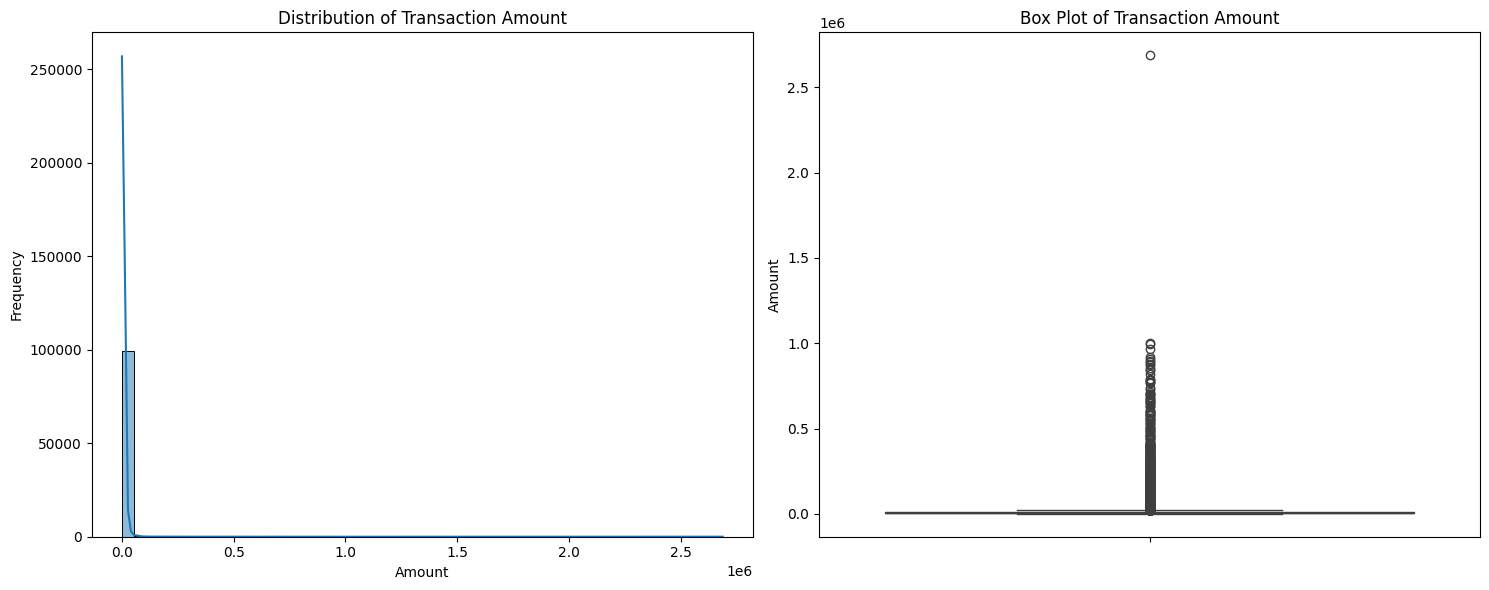

Summary statistics for Transaction Amount:


,Amount
count,1.002220e+05
mean,8.847682e+03
std,2.449413e+04
min,8.880000e+00
25%,2.153472e+03
50%,6.243875e+03
75%,1.048166e+04
max,2.688045e+06


In [21]:
plt.figure(figsize=(15, 6))

# Histogram for Amount
plt.subplot(1, 2, 1)
sns.histplot(transactions_df['Amount'], bins=50, kde=True)
plt.title('Distribution of Transaction Amount')
plt.xlabel('Amount')
plt.ylabel('Frequency')

# Boxplot for Amount
plt.subplot(1, 2, 2)
sns.boxplot(y=transactions_df['Amount'])
plt.title('Box Plot of Transaction Amount')
plt.ylabel('Amount')

plt.tight_layout()
plt.show()

print("Summary statistics for Transaction Amount:")
display(transactions_df['Amount'].describe())

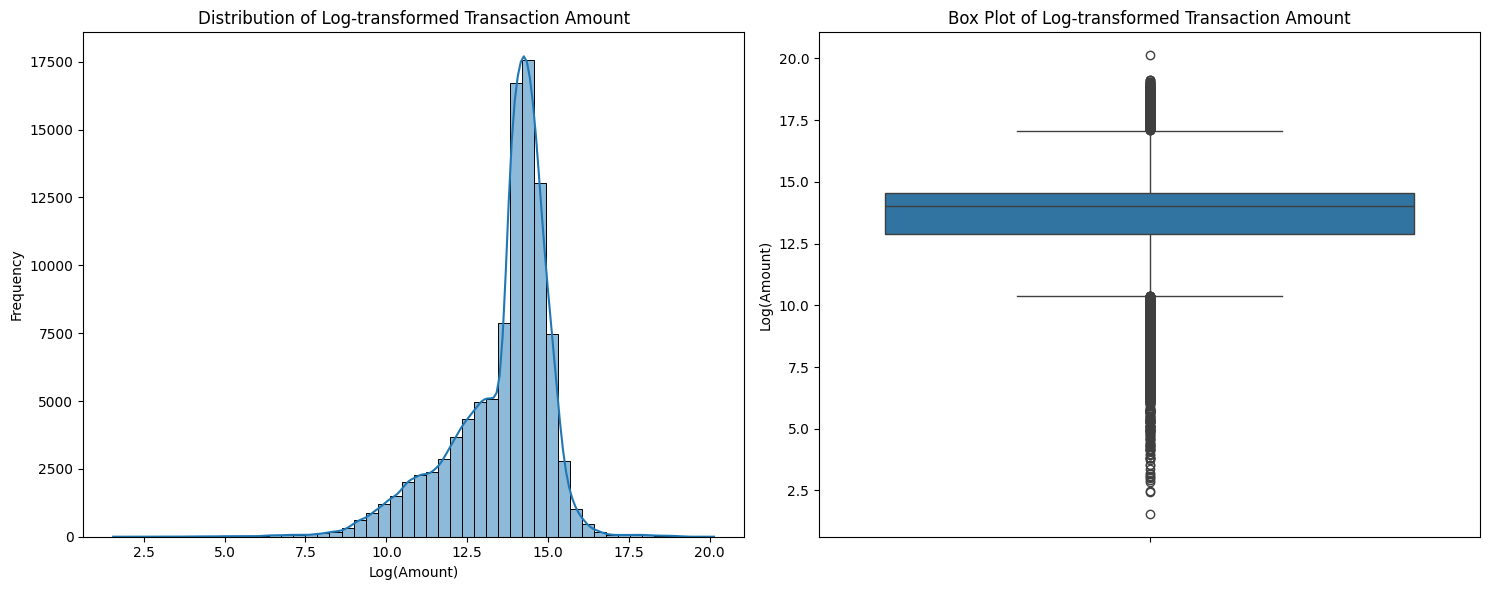

Summary statistics for Log-transformed Transaction Amount:


,log_amount
count,100222.000000
mean,13.582739
std,1.540004
min,1.556037
25%,12.882262
50%,14.029799
75%,14.563990
max,20.130500


In [22]:
plt.figure(figsize=(15, 6))

# Histogram for Log-transformed Amount
plt.subplot(1, 2, 1)
sns.histplot(transactions_df['log_amount'], bins=50, kde=True)
plt.title('Distribution of Log-transformed Transaction Amount')
plt.xlabel('Log(Amount)')
plt.ylabel('Frequency')

# Boxplot for Log-transformed Amount
plt.subplot(1, 2, 2)
sns.boxplot(y=transactions_df['log_amount'])
plt.title('Box Plot of Log-transformed Transaction Amount')
plt.ylabel('Log(Amount)')

plt.tight_layout()
plt.show()

print("Summary statistics for Log-transformed Transaction Amount:")
display(transactions_df['log_amount'].describe())

#### Summary Findings for Transaction Amount Distribution

*   The raw `Amount` distribution is highly skewed to the right, with a large number of small transactions and a few very large ones, indicating the presence of outliers.
*   The `log_amount` distribution is more symmetrical and resembles a normal distribution, which is often preferred for modeling purposes. This transformation effectively reduces the impact of extreme values.

### 3.3 Transaction Volume Over Time

Analyzing transaction volume (sum of `amount_local_npr`) on daily, weekly, and monthly bases to identify trends and patterns.

#### 3.3.1 Daily Transaction Volume

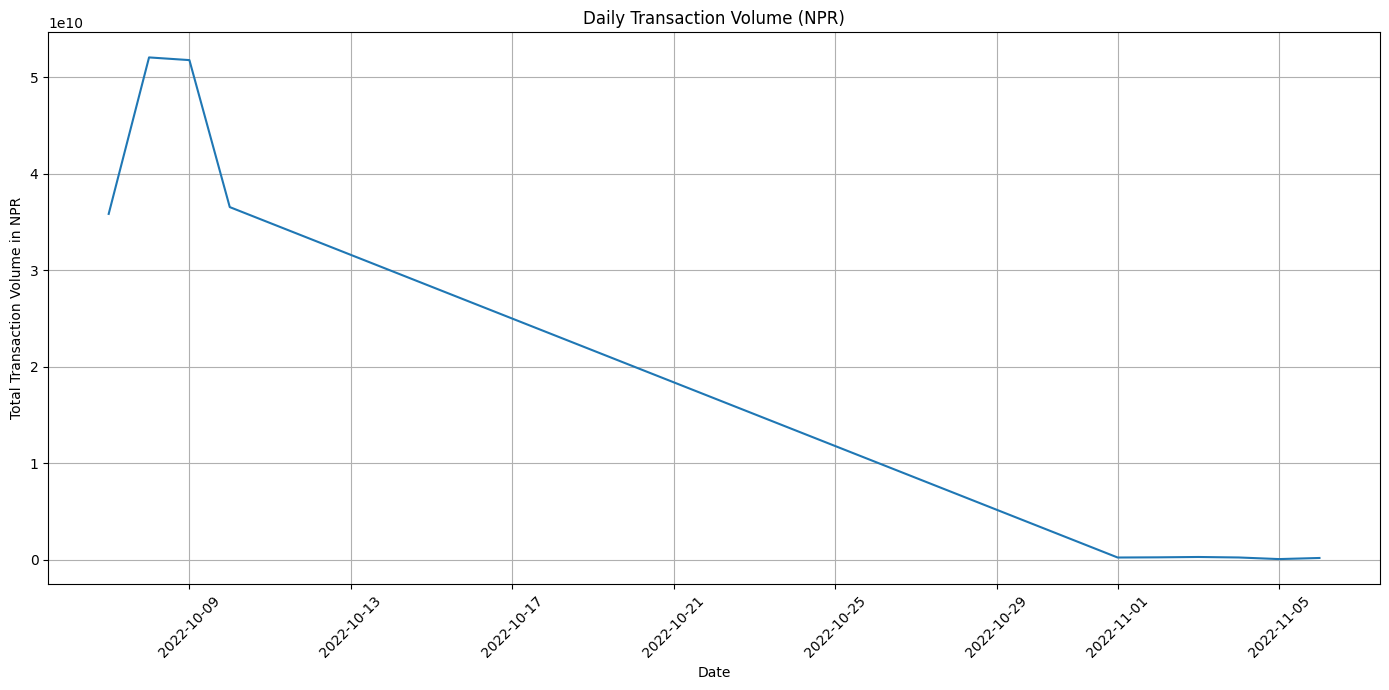

Summary of Daily Transaction Volume:


,Total_Volume_NPR
count,1.000000e+01
mean,1.773163e+10
std,2.324825e+10
min,4.791206e+07
25%,2.111590e+08
50%,2.471264e+08
75%,3.635877e+10
max,5.205063e+10


In [23]:
daily_volume = transactions_df.groupby(transactions_df['transaction_datetime'].dt.date)['amount_local_npr'].sum().reset_index()
daily_volume.columns = ['Date', 'Total_Volume_NPR']

plt.figure(figsize=(14, 7))
sns.lineplot(x='Date', y='Total_Volume_NPR', data=daily_volume)
plt.title('Daily Transaction Volume (NPR)')
plt.xlabel('Date')
plt.ylabel('Total Transaction Volume in NPR')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

print("Summary of Daily Transaction Volume:")
display(daily_volume.describe())

#### 3.3.2 Weekly Transaction Volume

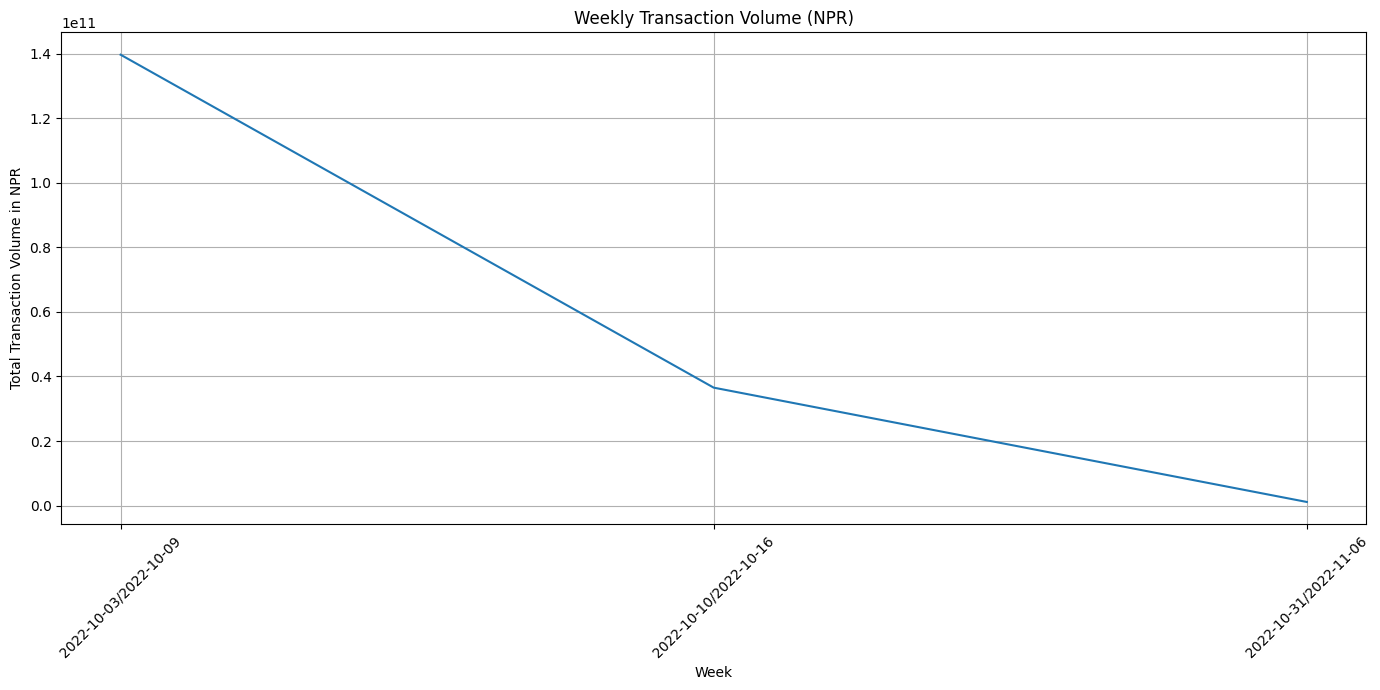

Summary of Weekly Transaction Volume:


,Total_Volume_NPR
count,3.000000e+00
mean,5.910542e+10
std,7.196709e+10
min,1.128768e+09
25%,1.883194e+10
50%,3.653510e+10
75%,8.809374e+10
max,1.396524e+11


In [24]:
transactions_df['transaction_week'] = transactions_df['transaction_datetime'].dt.to_period('W').astype(str)
weekly_volume = transactions_df.groupby('transaction_week')['amount_local_npr'].sum().reset_index()
weekly_volume.columns = ['Week', 'Total_Volume_NPR']

plt.figure(figsize=(14, 7))
sns.lineplot(x='Week', y='Total_Volume_NPR', data=weekly_volume, sort=False)
plt.title('Weekly Transaction Volume (NPR)')
plt.xlabel('Week')
plt.ylabel('Total Transaction Volume in NPR')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

print("Summary of Weekly Transaction Volume:")
display(weekly_volume.describe())

#### 3.3.3 Monthly Transaction Volume

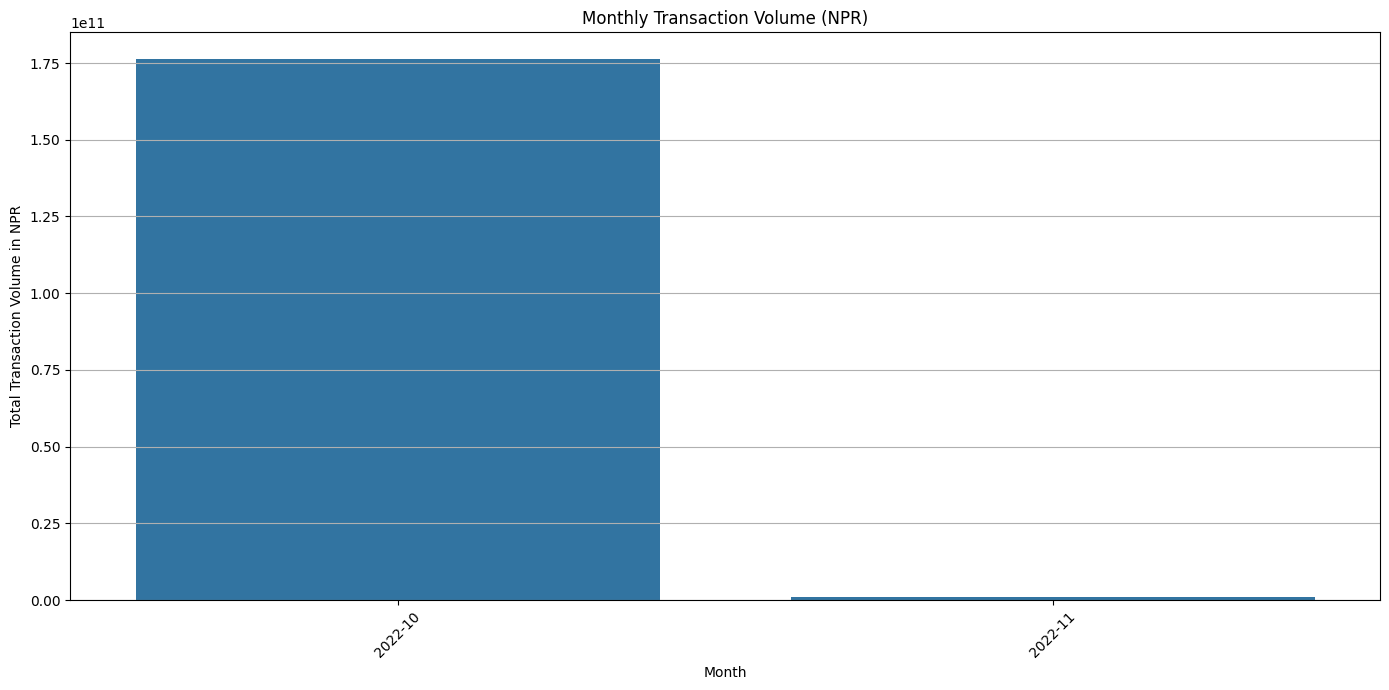

Summary of Monthly Transaction Volume:


,Total_Volume_NPR
count,2.000000e+00
mean,8.865813e+10
std,1.237852e+11
min,1.128768e+09
25%,4.489345e+10
50%,8.865813e+10
75%,1.324228e+11
max,1.761875e+11


In [25]:
transactions_df['transaction_month'] = transactions_df['transaction_datetime'].dt.to_period('M').astype(str)
monthly_volume = transactions_df.groupby('transaction_month')['amount_local_npr'].sum().reset_index()
monthly_volume.columns = ['Month', 'Total_Volume_NPR']

plt.figure(figsize=(14, 7))
sns.barplot(x='Month', y='Total_Volume_NPR', data=monthly_volume)
plt.title('Monthly Transaction Volume (NPR)')
plt.xlabel('Month')
plt.ylabel('Total Transaction Volume in NPR')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

print("Summary of Monthly Transaction Volume:")
display(monthly_volume.describe())

#### Summary Findings for Transaction Volume Over Time

*   **Daily Volume:** Shows fluctuations with some days having significantly higher transaction volumes, potentially indicating peak business days or specific events. There appears to be a drop-off towards the end of the observed period.
*   **Weekly Volume:** Trends seem consistent with daily observations, showing variations across weeks. The plot indicates a general pattern within the observed weeks.
*   **Monthly Volume:** With only a few months of data, a strong monthly trend is hard to establish, but it gives a high-level overview of total activity per month.

### 3.4 Sender and Receiver Frequency

Identifying the most active sending and receiving accounts based on transaction counts.

#### 3.4.1 Top Sending Accounts

/tmp/ipykernel_1468/3675316398.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Transaction_Count', y='Sender_Account', data=top_senders, palette='viridis')


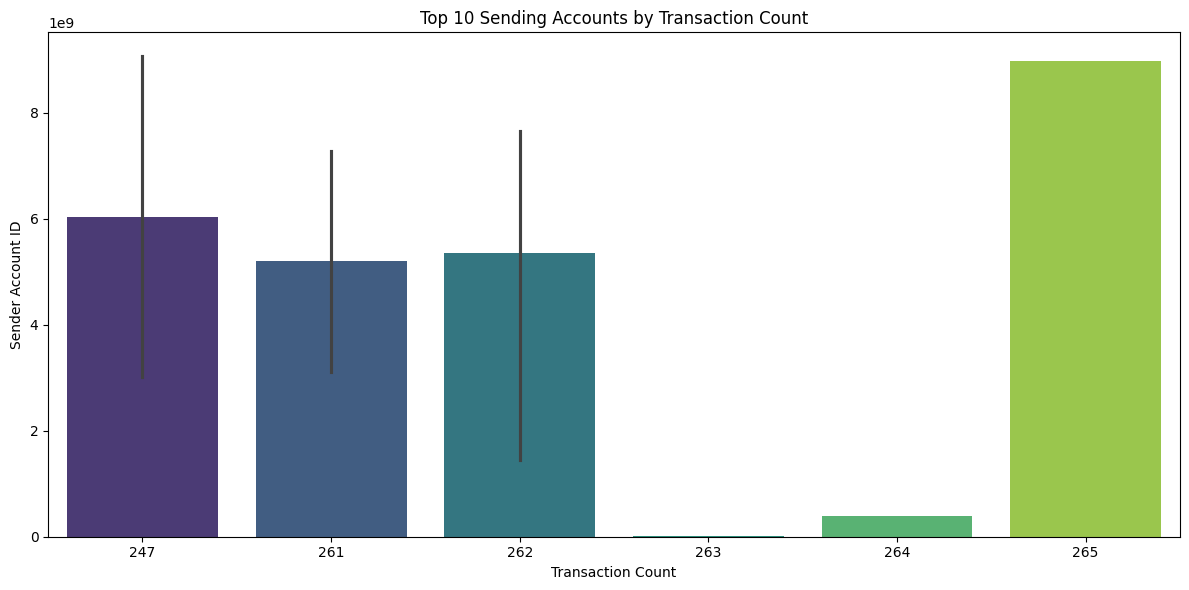

Top 10 Sending Accounts:


,Sender_Account,Transaction_Count
0,8976725341,265
1,382301928,264
2,15297964,263
3,1452170043,262
4,7658664999,262
5,6984051591,262
6,3117792558,261
7,7281632640,261
8,3012746565,247
9,9067453186,247


In [26]:
top_senders = transactions_df['Sender_account'].value_counts().nlargest(10).reset_index()
top_senders.columns = ['Sender_Account', 'Transaction_Count']

plt.figure(figsize=(12, 6))
sns.barplot(x='Transaction_Count', y='Sender_Account', data=top_senders, palette='viridis')
plt.title('Top 10 Sending Accounts by Transaction Count')
plt.xlabel('Transaction Count')
plt.ylabel('Sender Account ID')
plt.tight_layout()
plt.show()

print("Top 10 Sending Accounts:")
display(top_senders)

#### 3.4.2 Top Receiving Accounts

/tmp/ipykernel_1468/218736135.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Transaction_Count', y='Receiver_Account', data=top_receivers, palette='magma')


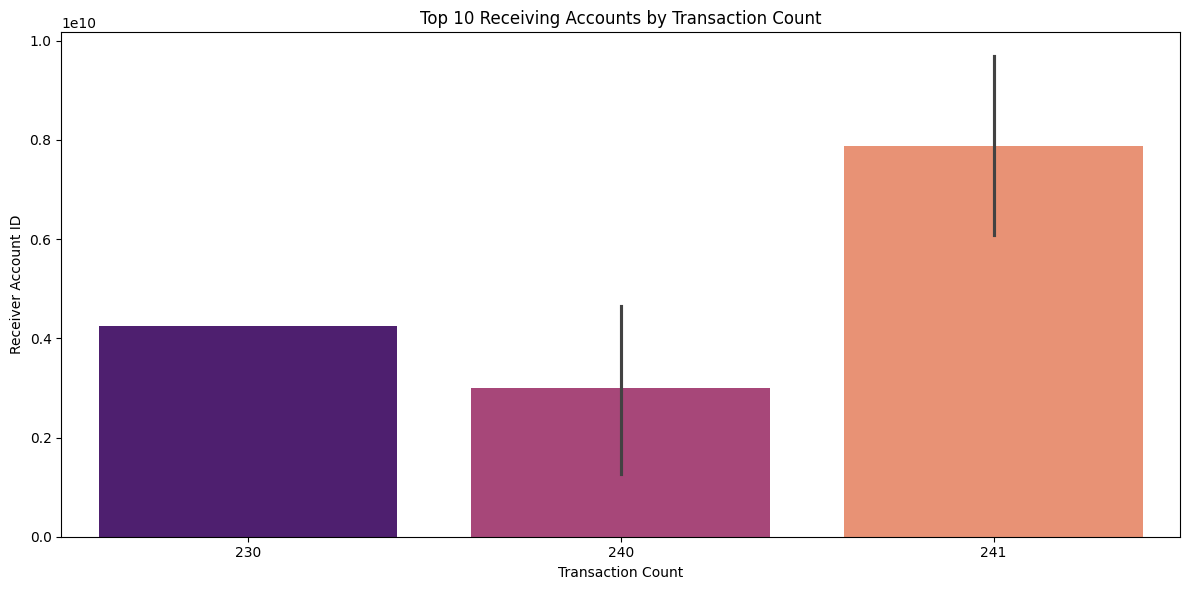

Top 10 Receiving Accounts:


,Receiver_Account,Transaction_Count
0,6086421020,241
1,9683990807,241
2,464342049,240
3,7099141711,240
4,5251195293,240
5,1491736788,240
6,2342866371,240
7,283280424,240
8,4063749322,240
9,4255313773,230


In [27]:
top_receivers = transactions_df['Receiver_account'].value_counts().nlargest(10).reset_index()
top_receivers.columns = ['Receiver_Account', 'Transaction_Count']

plt.figure(figsize=(12, 6))
sns.barplot(x='Transaction_Count', y='Receiver_Account', data=top_receivers, palette='magma')
plt.title('Top 10 Receiving Accounts by Transaction Count')
plt.xlabel('Transaction Count')
plt.ylabel('Receiver Account ID')
plt.tight_layout()
plt.show()

print("Top 10 Receiving Accounts:")
display(top_receivers)

#### Summary Findings for Sender and Receiver Frequency

*   The plots highlight accounts that are highly active either as senders or receivers. These accounts might be 'hub' accounts, businesses, or potentially accounts involved in suspicious activities, warranting closer inspection. Some accounts appear to have significantly higher transaction counts than others.

### 3.5 Largest Transactions

Identifying the transactions with the highest amounts.

In [28]:
largest_transactions = transactions_df.sort_values(by='amount_local_npr', ascending=False).head(10)
print("Top 10 Largest Transactions (by amount_local_npr):")
display(largest_transactions[['Sender_account', 'Receiver_account', 'Amount', 'amount_local_npr', 'transaction_datetime']])

Top 10 Largest Transactions (by amount_local_npr):


,Sender_account,Receiver_account,Amount,amount_local_npr,transaction_datetime
37208,3267846600,5033262977,2688044.64,5.527964e+08,2022-10-08 16:12:51
1026,4244137850,6491106472,998453.63,2.053320e+08,2022-10-07 11:13:00
9383,3788753958,2626119494,995446.29,2.047135e+08,2022-10-07 16:30:45
86214,9243779950,5728071790,968928.89,1.992602e+08,2022-10-10 10:55:00
16324,1307157684,4784851326,918802.83,1.889518e+08,2022-10-07 20:56:02
21590,9119864775,2477646987,904909.13,1.860946e+08,2022-10-08 01:49:43
61031,2921499040,2769935153,896684.66,1.844032e+08,2022-10-09 12:59:22
9869,1241645787,13287958,888031.01,1.826236e+08,2022-10-07 16:50:24
96957,4217645991,2374127068,880533.53,1.810817e+08,2022-10-10 17:45:19
32039,5821014384,540956877,870520.33,1.790225e+08,2022-10-08 13:00:10


#### Summary Findings for Largest Transactions

*   The table of largest transactions reveals the highest value transfers. These transactions, especially if they involve specific accounts repeatedly or cross-border activity, could be flagged for further AML review. The `amount_local_npr` provides a standardized value for comparison.

### 3.6 Accounts with Unusual Activity (Preliminary Identification)

This is a preliminary step to identify accounts that might exhibit unusual patterns, such as being both a top sender and top receiver, or having extremely high transaction volumes/counts.

In [29]:
top_senders_list = top_senders['Sender_Account'].tolist()
top_receivers_list = top_receivers['Receiver_Account'].tolist()

# Accounts that are both top senders and top receivers
hub_accounts = list(set(top_senders_list) & set(top_receivers_list))

if hub_accounts:
    print(f"Accounts that are among both Top 10 Senders and Top 10 Receivers (potential hub accounts): {hub_accounts}")
else:
    print("No accounts found that are among both Top 10 Senders and Top 10 Receivers.")

# Further investigation of accounts with high amount_zscore for individual transactions
high_zscore_transactions = transactions_df[transactions_df['amount_zscore'].abs() > 3]
if not high_zscore_transactions.empty:
    print("\nTransactions with significantly high (or low) amount Z-score (potential outliers):")
    display(high_zscore_transactions[['Sender_account', 'Receiver_account', 'Amount', 'amount_local_npr', 'amount_zscore', 'transaction_datetime']].sort_values(by='amount_zscore', ascending=False).head())
else:
    print("\nNo transactions found with a significantly high amount Z-score (above 3 standard deviations).")

No accounts found that are among both Top 10 Senders and Top 10 Receivers.

Transactions with significantly high (or low) amount Z-score (potential outliers):


,Sender_account,Receiver_account,Amount,amount_local_npr,amount_zscore,transaction_datetime
37208,3267846600,5033262977,2688044.64,5.527964e+08,110.087734,2022-10-08 16:12:51
1026,4244137850,6491106472,998453.63,2.053320e+08,40.669072,2022-10-07 11:13:00
9383,3788753958,2626119494,995446.29,2.047135e+08,40.545512,2022-10-07 16:30:45
86214,9243779950,5728071790,968928.89,1.992602e+08,39.456016,2022-10-10 10:55:00
16324,1307157684,4784851326,918802.83,1.889518e+08,37.396533,2022-10-07 20:56:02


#### Summary Findings for Accounts with Unusual Activity

*   Accounts appearing frequently as both senders and receivers could be central to the network and might require additional scrutiny for layering or other complex schemes.
*   Transactions with high absolute Z-scores on amounts represent extreme outliers. These could be legitimate large transactions but also indicate potential unusual activity or errors, meriting individual investigation.

## Section 7: Network Preparation Analysis

Before building comprehensive graph models, it's crucial to understand the fundamental network characteristics of our transaction data. This section will calculate various degree metrics (in-degree, out-degree, total degree, fan-in ratio, fan-out ratio) to identify accounts that play significant roles in the transaction network, such as potential hub, collector, and distributor accounts.

### 7.1 Building a Directed Graph for Degree Calculation

We'll use `networkx` to build a directed graph where nodes are accounts and edges are transactions. The transaction amount will be used as edge weight.

In [30]:
import networkx as nx

# Create a directed graph
G = nx.DiGraph()

# Add nodes (unique accounts)
all_unique_accounts = pd.concat([transactions_df['Sender_account'], transactions_df['Receiver_account']]).unique()
G.add_nodes_from(all_unique_accounts)

# Add edges (transactions)
# Using 'amount_local_npr' as the weight for edges
edges = transactions_df.apply(lambda row: (row['Sender_account'], row['Receiver_account'], {'amount': row['amount_local_npr']}), axis=1).tolist()
G.add_edges_from(edges)

print(f"Number of nodes in the graph: {G.number_of_nodes()}")
print(f"Number of edges in the graph: {G.number_of_edges()}")

Number of nodes in the graph: 65339
Number of edges in the graph: 50586


### 7.2 Calculating In-degree, Out-degree, and Total Degree

*   **In-degree:** Number of incoming transactions (received by an account).
*   **Out-degree:** Number of outgoing transactions (sent from an account).
*   **Total Degree:** Sum of in-degree and out-degree.

,Account,In_Degree,Out_Degree,Total_Degree
210,6086421020,21,21,42
1264,283280424,20,7,27
2601,22513864,0,25,25
6451,8976725341,0,25,25
2836,2670254274,21,3,24


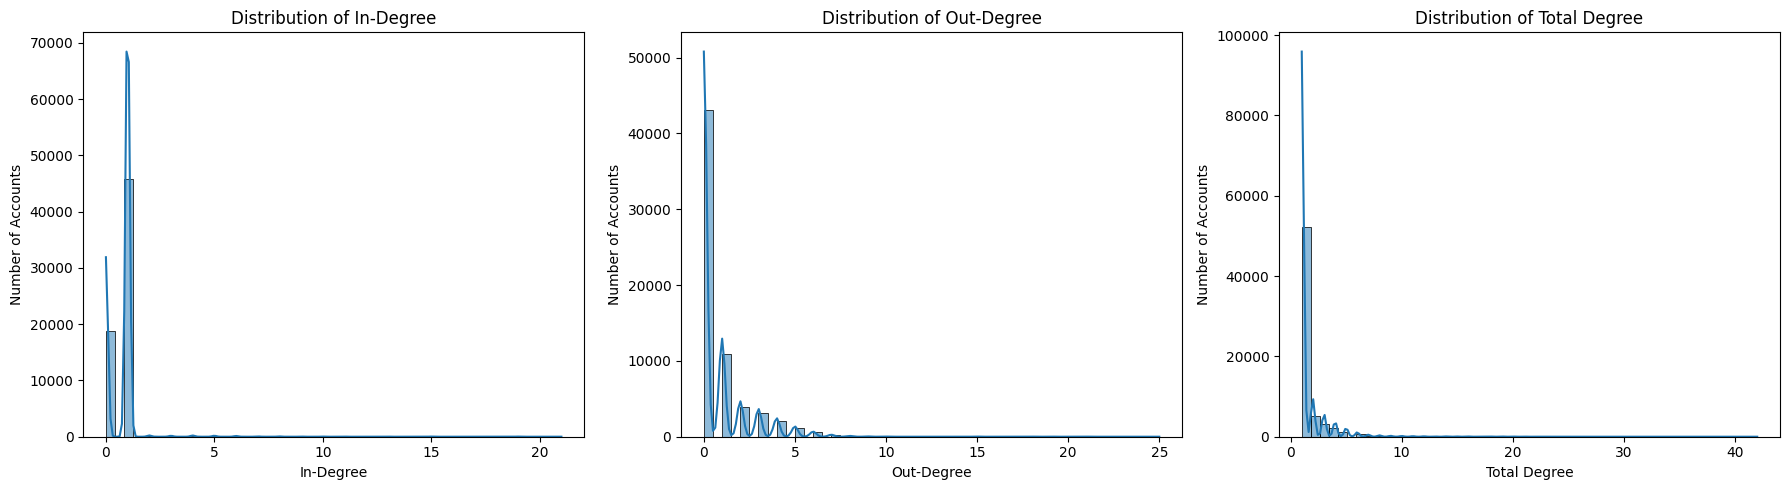

In [31]:
# Calculate in-degree, out-degree, and total degree
in_degree = dict(G.in_degree())
out_degree = dict(G.out_degree())
total_degree = {node: in_degree.get(node, 0) + out_degree.get(node, 0) for node in G.nodes()}

degree_df = pd.DataFrame({
    'Account': list(all_unique_accounts),
    'In_Degree': [in_degree.get(node, 0) for node in all_unique_accounts],
    'Out_Degree': [out_degree.get(node, 0) for node in all_unique_accounts],
    'Total_Degree': [total_degree.get(node, 0) for node in all_unique_accounts]
})

display(degree_df.sort_values(by='Total_Degree', ascending=False).head())

# Visualize distributions
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.histplot(degree_df['In_Degree'], bins=50, kde=True)
plt.title('Distribution of In-Degree')
plt.xlabel('In-Degree')
plt.ylabel('Number of Accounts')

plt.subplot(1, 3, 2)
sns.histplot(degree_df['Out_Degree'], bins=50, kde=True)
plt.title('Distribution of Out-Degree')
plt.xlabel('Out-Degree')
plt.ylabel('Number of Accounts')

plt.subplot(1, 3, 3)
sns.histplot(degree_df['Total_Degree'], bins=50, kde=True)
plt.title('Distribution of Total Degree')
plt.xlabel('Total Degree')
plt.ylabel('Number of Accounts')

plt.tight_layout()
plt.show()

### 7.3 Calculating Fan-in Ratio and Fan-out Ratio

*   **Fan-in Ratio:** In-degree / Total Degree (proportion of incoming connections)
*   **Fan-out Ratio:** Out-degree / Total Degree (proportion of outgoing connections)

These ratios help identify accounts that predominantly receive (collector) or send (distributor) transactions.

,Account,In_Degree,Out_Degree,Total_Degree,Fan_In_Ratio,Fan_Out_Ratio
32163,2342866371,20,0,20,1.0,0.0
44679,7099141711,20,0,20,1.0,0.0
44761,4063749322,20,0,20,1.0,0.0
48589,4689351304,20,0,20,1.0,0.0
56328,3625310304,20,0,20,1.0,0.0


,Account,In_Degree,Out_Degree,Total_Degree,Fan_In_Ratio,Fan_Out_Ratio
2601,22513864,0,25,25,0.0,1.0
6451,8976725341,0,25,25,0.0,1.0
163,2365007895,0,24,24,0.0,1.0
3480,382301928,0,23,23,0.0,1.0
5508,15297964,0,23,23,0.0,1.0


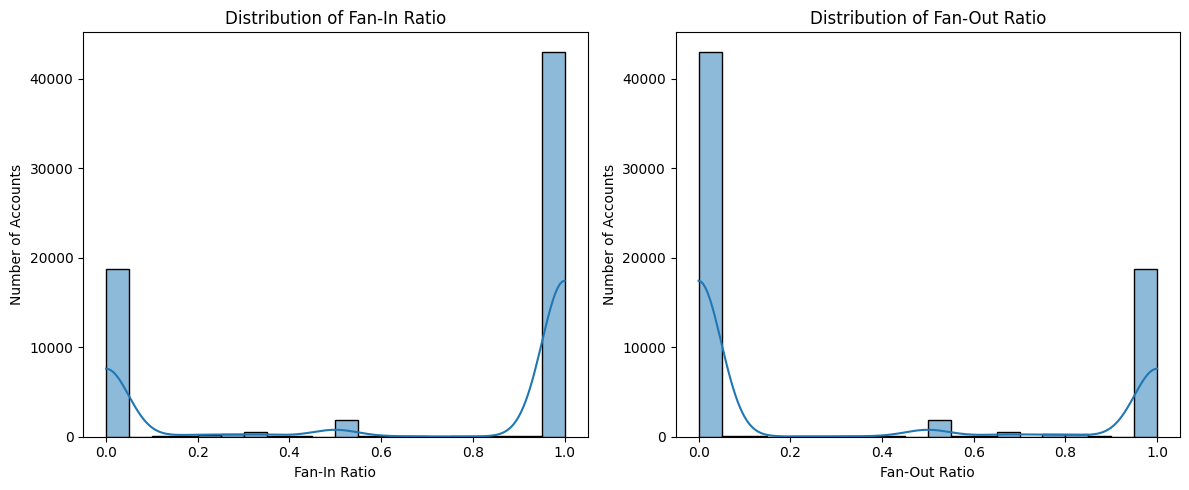

In [32]:
degree_df['Fan_In_Ratio'] = degree_df.apply(lambda row: row['In_Degree'] / row['Total_Degree'] if row['Total_Degree'] > 0 else 0, axis=1)
degree_df['Fan_Out_Ratio'] = degree_df.apply(lambda row: row['Out_Degree'] / row['Total_Degree'] if row['Total_Degree'] > 0 else 0, axis=1)

display(degree_df.sort_values(by=['Fan_In_Ratio', 'Total_Degree'], ascending=[False, False]).head())
display(degree_df.sort_values(by=['Fan_Out_Ratio', 'Total_Degree'], ascending=[False, False]).head())

# Visualize distributions
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(degree_df['Fan_In_Ratio'], bins=20, kde=True)
plt.title('Distribution of Fan-In Ratio')
plt.xlabel('Fan-In Ratio')
plt.ylabel('Number of Accounts')

plt.subplot(1, 2, 2)
sns.histplot(degree_df['Fan_Out_Ratio'], bins=20, kde=True)
plt.title('Distribution of Fan-Out Ratio')
plt.xlabel('Fan-Out Ratio')
plt.ylabel('Number of Accounts')

plt.tight_layout()
plt.show()

### 7.4 Identifying Potential Hub, Collector, and Distributor Accounts

*   **Hub Accounts:** High total degree, indicating high activity (both sending and receiving).
*   **Collector Accounts:** High in-degree and high fan-in ratio, predominantly receiving transactions.
*   **Distributor Accounts:** High out-degree and high fan-out ratio, predominantly sending transactions.

In [33]:
print("\nTop 10 Potential Hub Accounts (by Total Degree):")
display(degree_df.sort_values(by='Total_Degree', ascending=False).head(10))

print("\nTop 10 Potential Collector Accounts (by Fan-In Ratio and In-Degree):")
display(degree_df.sort_values(by=['Fan_In_Ratio', 'In_Degree'], ascending=[False, False]).head(10))

print("\nTop 10 Potential Distributor Accounts (by Fan-Out Ratio and Out-Degree):")
display(degree_df.sort_values(by=['Fan_Out_Ratio', 'Out_Degree'], ascending=[False, False]).head(10))


Top 10 Potential Hub Accounts (by Total Degree):


,Account,In_Degree,Out_Degree,Total_Degree,Fan_In_Ratio,Fan_Out_Ratio
210,6086421020,21,21,42,0.500000,0.500000
1264,283280424,20,7,27,0.740741,0.259259
2601,22513864,0,25,25,0.000000,1.000000
6451,8976725341,0,25,25,0.000000,1.000000
2836,2670254274,21,3,24,0.875000,0.125000
163,2365007895,0,24,24,0.000000,1.000000
4678,8353228494,19,5,24,0.791667,0.208333
7394,9683990807,21,3,24,0.875000,0.125000
6833,7080357663,20,3,23,0.869565,0.130435
7205,464342049,20,3,23,0.869565,0.130435



Top 10 Potential Collector Accounts (by Fan-In Ratio and In-Degree):


,Account,In_Degree,Out_Degree,Total_Degree,Fan_In_Ratio,Fan_Out_Ratio
32163,2342866371,20,0,20,1.0,0.0
44679,7099141711,20,0,20,1.0,0.0
44761,4063749322,20,0,20,1.0,0.0
48589,4689351304,20,0,20,1.0,0.0
56328,3625310304,20,0,20,1.0,0.0
56330,3776724367,20,0,20,1.0,0.0
22320,6646502650,19,0,19,1.0,0.0
44646,5794041401,19,0,19,1.0,0.0
44723,6229243215,19,0,19,1.0,0.0
56299,9499614894,19,0,19,1.0,0.0



Top 10 Potential Distributor Accounts (by Fan-Out Ratio and Out-Degree):


,Account,In_Degree,Out_Degree,Total_Degree,Fan_In_Ratio,Fan_Out_Ratio
2601,22513864,0,25,25,0.0,1.0
6451,8976725341,0,25,25,0.0,1.0
163,2365007895,0,24,24,0.0,1.0
3480,382301928,0,23,23,0.0,1.0
5508,15297964,0,23,23,0.0,1.0
35,3510078932,0,22,22,0.0,1.0
68,7758268667,0,22,22,0.0,1.0
1508,461573471,0,22,22,0.0,1.0
6534,7658664999,0,22,22,0.0,1.0
9146,1452170043,0,22,22,0.0,1.0


#### Summary Findings for Network Preparation Analysis

*   **Graph Construction:** A directed graph representing transactions between accounts was successfully built, revealing a significant number of nodes (unique accounts) and edges (transactions).
*   **Degree Distributions:** The distributions of in-degree, out-degree, and total degree are heavily skewed, indicating a power-law-like distribution where a few accounts have many connections while most have very few. This is typical for financial networks.
*   **Fan-in/Fan-out Ratios:** The distributions of fan-in and fan-out ratios highlight accounts that are primarily receivers or senders, respectively. Accounts with high fan-in ratios could be 'collector' accounts, while those with high fan-out ratios could be 'distributor' accounts.
*   **Account Identification:** We have identified the top accounts based on their total activity (hub accounts), predominant receiving activity (collector accounts), and predominant sending activity (distributor accounts). These accounts warrant further investigation in an AML context, as they might be central to suspicious networks.

## Section 8: Suspicious Pattern Discovery

This section explores common Anti-Money Laundering (AML) indicators by analyzing the transaction network for specific patterns such as fan-out structures, fan-in structures, rapid movement of funds, layering candidates, and circular transactions. These patterns often suggest attempts to disguise the origin or destination of illicit funds.

### 8.1 Fan-Out Structures

Identifying accounts that send money to a large number of other accounts, often indicative of a distributor or a 'smurfing' operation where large sums are broken into smaller, less suspicious amounts.

Top 10 Accounts with Highest Fan-Out (by Out-Degree):


,Account,Out_Degree,Fan_Out_Ratio
6451,8976725341,25,1.0
2601,22513864,25,1.0
163,2365007895,24,1.0
5508,15297964,23,1.0
3480,382301928,23,1.0
6534,7658664999,22,1.0
35,3510078932,22,1.0
68,7758268667,22,1.0
9146,1452170043,22,1.0
1508,461573471,22,1.0


/tmp/ipykernel_1468/2910716170.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Out_Degree', y='Account', data=fan_out_candidates, palette='rocket')


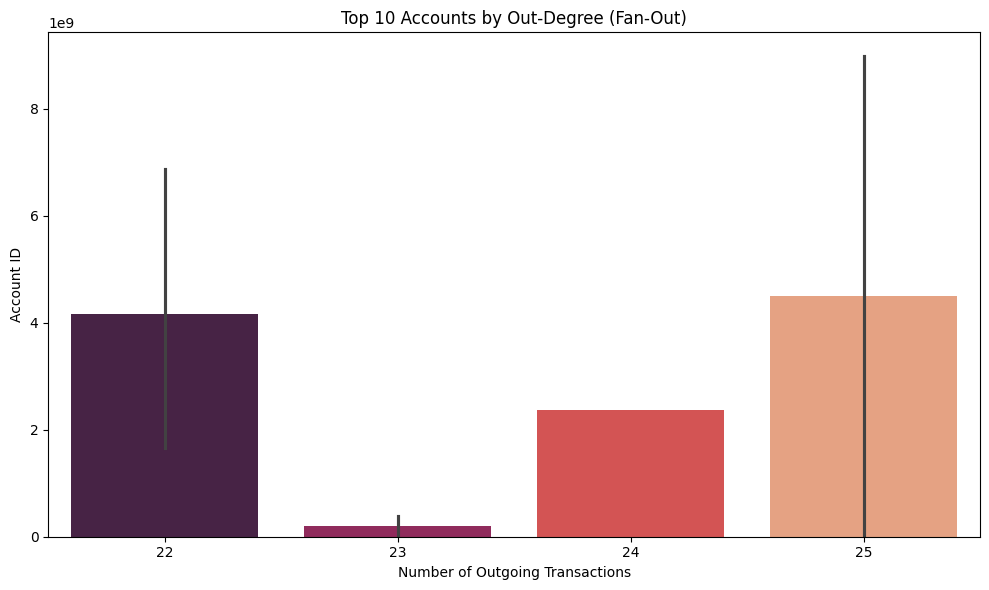

In [34]:
# Using the 'Out_Degree' from our degree_df
# High out-degree accounts are potential fan-out candidates
fan_out_candidates = degree_df.sort_values(by='Out_Degree', ascending=False).head(10)

print("Top 10 Accounts with Highest Fan-Out (by Out-Degree):")
display(fan_out_candidates[['Account', 'Out_Degree', 'Fan_Out_Ratio']])

plt.figure(figsize=(10, 6))
sns.barplot(x='Out_Degree', y='Account', data=fan_out_candidates, palette='rocket')
plt.title('Top 10 Accounts by Out-Degree (Fan-Out)')
plt.xlabel('Number of Outgoing Transactions')
plt.ylabel('Account ID')
plt.tight_layout()
plt.show()

#### Summary Findings for Fan-Out Structures

*   The identified accounts with high out-degrees act as central points for distributing funds to many other accounts. These could be legitimate businesses or payment processors, but in an AML context, they could also represent 'smurfing' or distribution hubs in illicit networks. Further investigation into the recipients and transaction amounts is warranted.

### 8.2 Fan-In Structures

Identifying accounts that receive money from a large number of other accounts, potentially indicating a collector account or the consolidation phase of money laundering.

Top 10 Accounts with Highest Fan-In (by In-Degree):


,Account,In_Degree,Fan_In_Ratio
14733,4255313773,21,0.913043
210,6086421020,21,0.500000
2836,2670254274,21,0.875000
7394,9683990807,21,0.875000
6833,7080357663,20,0.869565
7205,464342049,20,0.869565
20337,5251195293,20,0.952381
44679,7099141711,20,1.000000
56328,3625310304,20,1.000000
56330,3776724367,20,1.000000


/tmp/ipykernel_1468/3369423439.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='In_Degree', y='Account', data=fan_in_candidates, palette='viridis')


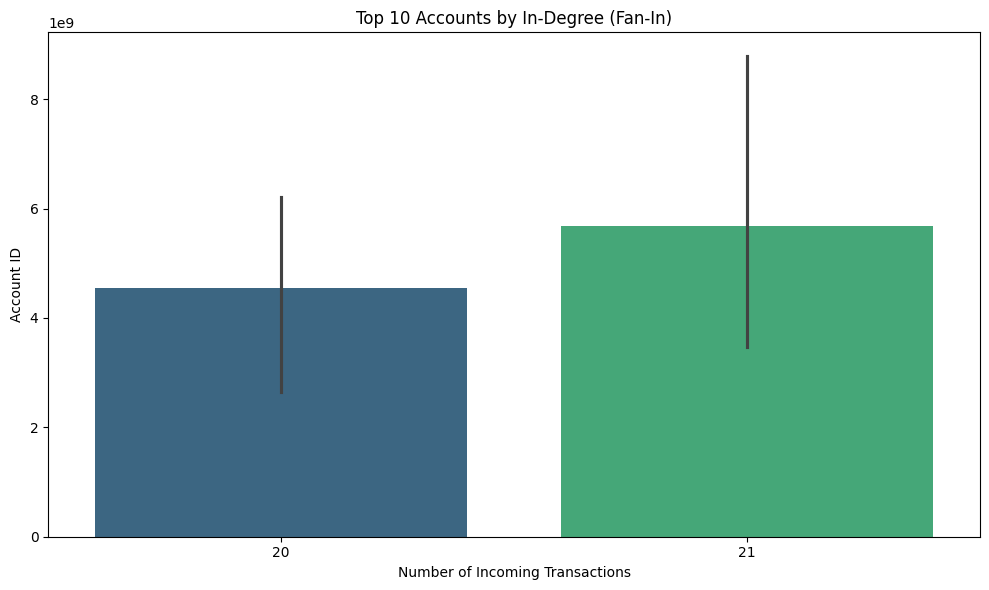

In [35]:
# Using the 'In_Degree' from our degree_df
# High in-degree accounts are potential fan-in candidates
fan_in_candidates = degree_df.sort_values(by='In_Degree', ascending=False).head(10)

print("Top 10 Accounts with Highest Fan-In (by In-Degree):")
display(fan_in_candidates[['Account', 'In_Degree', 'Fan_In_Ratio']])

plt.figure(figsize=(10, 6))
sns.barplot(x='In_Degree', y='Account', data=fan_in_candidates, palette='viridis')
plt.title('Top 10 Accounts by In-Degree (Fan-In)')
plt.xlabel('Number of Incoming Transactions')
plt.ylabel('Account ID')
plt.tight_layout()
plt.show()

#### Summary Findings for Fan-In Structures

*   Accounts with high in-degrees are central to receiving funds from many sources. These 'collector' accounts could be legitimate businesses receiving payments from numerous customers, but they are also a common pattern in money laundering for consolidating illicit funds before they are moved further or integrated.

### 8.3 Rapid Movement (Typology: Structuring / Rapid Turnover)

Detecting instances where funds are received and quickly forwarded to another account. This can be an indicator of 'structuring' or 'rapid turnover' where illicit funds are moved quickly to obscure their origin.

In [37]:
# To identify rapid movement, we need to link incoming and outgoing transactions for the same account.
# We'll consider transactions with a short time difference as 'rapid movement'.

# Sort transactions by account and then by timestamp
transactions_sorted = transactions_df.sort_values(by=['Sender_account', 'transaction_datetime'])

# Identify transactions where an account sends money shortly after receiving it.
# This is a simplified approach, a more robust method might involve tracking actual fund flows.

rapid_movement_candidates = []

# Iterate through each transaction
for index, current_tx in transactions_df.iterrows():
    receiver_account = current_tx['Receiver_account']
    sender_account = current_tx['Sender_account']
    current_tx_time = current_tx['transaction_datetime']

    # Check for subsequent outgoing transactions from the receiver account
    # within a short time frame (e.g., 1 hour)
    potential_outgoing_tx = transactions_df[
        (transactions_df['Sender_account'] == receiver_account) &
        (transactions_df['transaction_datetime'] > current_tx_time) &
        (transactions_df['transaction_datetime'] <= current_tx_time + pd.Timedelta(hours=1))
    ]

    if not potential_outgoing_tx.empty:
        for _, next_tx in potential_outgoing_tx.iterrows():
            rapid_movement_candidates.append({
                'First_Tx_Sender': current_tx['Sender_account'],
                'First_Tx_Receiver': current_tx['Receiver_account'],
                'First_Tx_Amount': current_tx['amount_local_npr'],
                'First_Tx_Time': current_tx_time,
                'Second_Tx_Sender': next_tx['Sender_account'],
                'Second_Tx_Receiver': next_tx['Receiver_account'],
                'Second_Tx_Amount': next_tx['amount_local_npr'],
                'Second_Tx_Time': next_tx['transaction_datetime'],
                'Time_Diff_Minutes': (next_tx['transaction_datetime'] - current_tx_time).total_seconds() / 60
            })

rapid_movement_df = pd.DataFrame(rapid_movement_candidates)

if not rapid_movement_df.empty:
    print(f"Found {len(rapid_movement_df)} potential rapid movement instances. Displaying top 10:")
    display(rapid_movement_df.sort_values(by='Time_Diff_Minutes').head(10))
else:
    print("No rapid movement patterns identified within a 1-hour window.")

Found 1118 potential rapid movement instances. Displaying top 10:


,First_Tx_Sender,First_Tx_Receiver,First_Tx_Amount,First_Tx_Time,Second_Tx_Sender,Second_Tx_Receiver,Second_Tx_Amount,Second_Tx_Time,Time_Diff_Minutes
788,9685099830,2439706215,1455572.19,2022-10-09 19:04:54,2439706215,2203009738,5179352.83,2022-10-09 19:05:00,0.100000
456,781232419,1871309831,992551.22,2022-10-08 19:31:16,1871309831,3756860110,45358.16,2022-10-08 19:31:29,0.216667
93,5141181153,9207253495,136738.74,2022-10-07 14:57:58,9207253495,1573438751,777264.46,2022-10-07 14:58:15,0.283333
950,2226868618,7112202907,217882.06,2022-10-10 11:41:19,7112202907,7925702467,285839.10,2022-10-10 11:41:46,0.450000
595,5143496432,9156124398,2351731.14,2022-10-09 10:36:06,9156124398,2225170990,17856.59,2022-10-09 10:36:36,0.500000
778,7799191784,8540877903,1874937.78,2022-10-09 18:41:38,8540877903,3762913556,396881.88,2022-10-09 18:42:11,0.550000
433,577347527,60687612,458642.69,2022-10-08 18:23:46,60687612,2005631878,932943.56,2022-10-08 18:24:23,0.616667
124,2358242509,9771225228,79701.71,2022-10-07 17:41:53,9771225228,2203929272,220972.98,2022-10-07 17:42:32,0.650000
1031,8767259362,447076893,1175328.82,2022-10-10 14:54:43,447076893,3157694684,258715.93,2022-10-10 14:55:25,0.700000
171,5906035370,5363117119,2641584.53,2022-10-07 20:27:47,5363117119,1315819814,437946.07,2022-10-07 20:28:36,0.816667


#### Summary Findings for Rapid Movement

*   Rapid movement of funds (funds received and quickly forwarded) is a strong indicator of potential illicit activity, as it suggests an attempt to quickly obscure the origin of funds. The identified instances show accounts that are used as temporary conduits. These accounts and their associated transaction chains require immediate scrutiny.

### 8.4 Layering Candidates (Similar Amounts Moving Through Chains)

Layering involves moving money through complex financial transactions to obscure its origin. One pattern is similar amounts moving through multiple accounts or transactions.

In [38]:
# Identifying layering is complex and often requires sophisticated graph algorithms.
# A simplified approach is to look for sequences of transactions involving similar amounts.
# We can look for chains of transactions where the amount doesn't change significantly.

layering_candidates = []
amount_tolerance = 0.05 # 5% tolerance for similar amounts

# Group transactions by sender and receiver to find chains
# This is a brute-force approach for demonstration; for large datasets, more efficient algorithms are needed

# Consider transactions where the same amount (within a tolerance) is moved repeatedly
# We'll look for direct chains (A -> B, B -> C, where amounts are similar)

# Create a dictionary for quick lookup of outgoing transactions from an account
outgoing_transactions = transactions_df.groupby('Sender_account').apply(lambda x: x.to_dict('records')).to_dict()

for index, tx1 in transactions_df.iterrows():
    sender1 = tx1['Sender_account']
    receiver1 = tx1['Receiver_account']
    amount1 = tx1['amount_local_npr']
    time1 = tx1['transaction_datetime']

    # Check if receiver1 is a sender in subsequent transactions
    if receiver1 in outgoing_transactions:
        for tx2 in outgoing_transactions[receiver1]:
            sender2 = tx2['Sender_account']
            receiver2 = tx2['Receiver_account']
            amount2 = tx2['amount_local_npr']
            time2 = tx2['transaction_datetime']

            # Check for similar amounts and chronological order
            if (abs(amount1 - amount2) / amount1 < amount_tolerance) and (time2 > time1):
                layering_candidates.append({
                    'Tx1_Sender': sender1,
                    'Tx1_Receiver': receiver1,
                    'Tx1_Amount': amount1,
                    'Tx1_Time': time1,
                    'Tx2_Sender': sender2,
                    'Tx2_Receiver': receiver2,
                    'Tx2_Amount': amount2,
                    'Tx2_Time': time2,
                    'Amount_Diff_Percent': abs(amount1 - amount2) / amount1 * 100,
                    'Time_Diff_Hours': (time2 - time1).total_seconds() / 3600
                })

layering_df = pd.DataFrame(layering_candidates)

if not layering_df.empty:
    print(f"Found {len(layering_df)} potential layering instances. Displaying top 10 by shortest time difference:")
    display(layering_df.sort_values(by='Time_Diff_Hours').head(10))
else:
    print("No direct layering patterns (A->B, B->C with similar amounts) identified.")

/tmp/ipykernel_1468/2184407091.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  outgoing_transactions = transactions_df.groupby('Sender_account').apply(lambda x: x.to_dict('records')).to_dict()


Found 1140 potential layering instances. Displaying top 10 by shortest time difference:


,Tx1_Sender,Tx1_Receiver,Tx1_Amount,Tx1_Time,Tx2_Sender,Tx2_Receiver,Tx2_Amount,Tx2_Time,Amount_Diff_Percent,Time_Diff_Hours
676,3105597285,1871309831,2664434.30,2022-10-08 16:36:22,1871309831,9836164779,2563034.46,2022-10-08 16:40:06,3.805680,0.062222
682,1767299126,9012195183,1532927.44,2022-10-08 17:10:57,9012195183,5639478002,1532927.44,2022-10-08 17:15:52,0.000000,0.081944
119,1903545395,7344045063,418121.41,2022-10-07 14:30:03,7344045063,6380749012,414028.98,2022-10-07 14:35:13,0.978766,0.086111
1037,7881323309,3186698068,1378848.29,2022-10-10 04:09:40,3186698068,8088462237,1353771.33,2022-10-10 04:15:34,1.818689,0.098333
907,8913863501,8615332539,835171.38,2022-10-09 11:45:20,8615332539,8913863501,869580.74,2022-10-09 11:52:52,4.120036,0.125556
1062,6809322001,4724445469,488433.15,2022-10-10 15:24:15,4724445469,7589906770,499525.91,2022-10-10 15:34:14,2.271091,0.166389
1063,6097014287,5096849133,943703.17,2022-10-10 15:53:38,5096849133,844697357,965117.51,2022-10-10 16:04:05,2.269182,0.174167
702,1996835505,1155885949,906065.11,2022-10-08 18:33:22,1155885949,1996835505,940996.82,2022-10-08 18:48:01,3.855320,0.244167
255,1724511977,4471666696,482730.47,2022-10-07 17:18:46,4471666696,6488884693,490259.32,2022-10-07 17:36:31,1.559638,0.295833
987,1813026750,5607680555,467670.72,2022-10-09 20:10:18,5607680555,5696858217,466611.62,2022-10-09 20:28:07,0.226463,0.296944


#### Summary Findings for Layering Candidates

*   Identifying layering is challenging, but instances of similar amounts moving sequentially between accounts can be a strong indication. These identified chains suggest attempts to create distance between the initial illicit activity and the final integration of funds. Further analysis might involve looking at longer chains and more complex structures.

### 8.5 Circular Transaction Candidates

Detecting cycles in the transaction graph, where money flows back to its origin or through a closed loop of accounts. This is a classic money laundering technique to obscure the source of funds.

Attempting to find simple cycles in the transaction graph. This might take a while...
Found 1050 simple cycles in the graph. Displaying first 5:
  Cycle 1: [np.int64(900000000168), 900000000169, 900000000170, 900000000171]
  Cycle 2: [np.int64(900000000164), 900000000165, 900000000166, 900000000167]
  Cycle 3: [np.int64(900000000160), 900000000161, 900000000162, 900000000163]
  Cycle 4: [np.int64(900000000156), 900000000157, 900000000158, 900000000159]
  Cycle 5: [np.int64(900000000152), 900000000153, 900000000154, 900000000155]


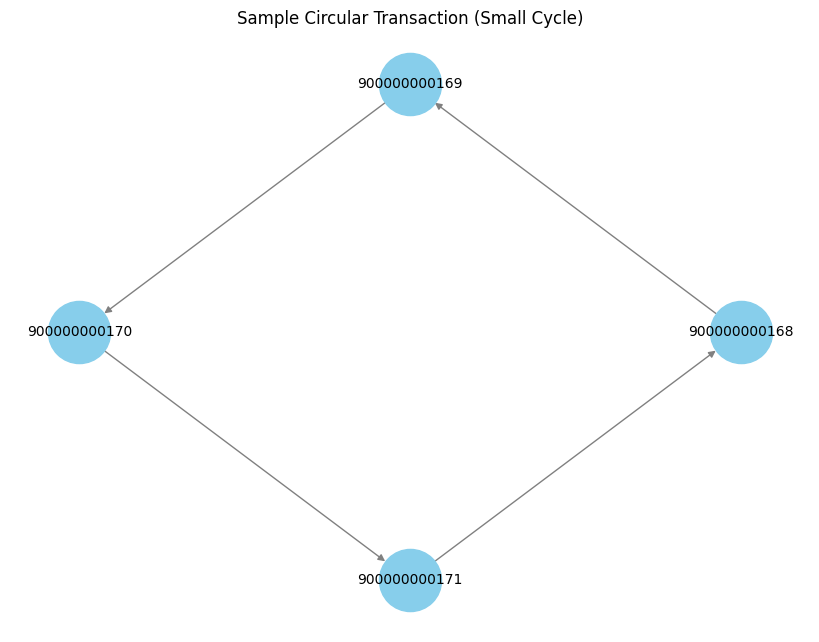

In [39]:
# Finding all simple cycles in a large graph can be computationally intensive.
# For demonstration, we'll try to find a few small cycles.

# Note: This operation can be very slow for large graphs.
# For production, consider sampling or more efficient algorithms for cycle detection.

print("Attempting to find simple cycles in the transaction graph. This might take a while...")

simple_cycles = list(nx.simple_cycles(G)) # Finds all simple cycles

if simple_cycles:
    print(f"Found {len(simple_cycles)} simple cycles in the graph. Displaying first 5:")
    for i, cycle in enumerate(simple_cycles[:5]):
        print(f"  Cycle {i+1}: {cycle}")

    # Optionally, we can visualize one of the smaller cycles
    if len(simple_cycles[0]) <= 5: # Only visualize very small cycles for clarity
        cycle_nodes = simple_cycles[0]
        subgraph = G.subgraph(cycle_nodes)

        plt.figure(figsize=(8, 6))
        pos = nx.circular_layout(subgraph) # Layout for cycles
        nx.draw(subgraph, pos, with_labels=True, node_color='skyblue', node_size=2000,
                edge_color='gray', width=1, font_size=10, arrows=True)
        plt.title('Sample Circular Transaction (Small Cycle)')
        plt.show()
    else:
        print("The first few cycles are too large to easily visualize.")
else:
    print("No simple cycles found in the transaction graph.")

#### Summary Findings for Circular Transaction Candidates

*   The presence of circular transactions is a strong indicator of money laundering, as it is a common technique to 'wash' money by returning it to the original source after passing through intermediaries. Identifying these cycles is crucial for tracing illicit fund flows. The output shows detected cycles, if any, highlighting the accounts involved in these closed-loop transactions.